In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statsmodels.tsa.seasonal import STL

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Donnees_ hydro_Togo/"
DATE_FORMAT = None
DATE_COL = "Date"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
Ttou = path+"Qj_Tetetou.csv"
Dtkp = path+"Qj_Dotaicope.csv"
Klkp = path+"Qj_kolokope.csv"

Ttou_df = pd.read_csv(Ttou, sep=';', skiprows=[0])
Dtkp_df = pd.read_csv(Dtkp, sep=';', skiprows=[0])
Klkp_df = pd.read_csv(Klkp, sep=';', skiprows=[0])

stations = ["Tetetou", "Dotaicope", "Kolokope"]

In [ ]:
# @title Traitement des VM (N/A)
for stat in stations:
  if stat == "Tetetou":
    if DATE_FORMAT:
        Ttou_df[DATE_COL] = pd.to_datetime(Ttou_df[DATE_COL], format=DATE_FORMAT)
        Ttou_df = Ttou_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Ttou_df = Ttou_df[Ttou_df['Qj(m3/s)'] >= 0]
        Ttou_df['Qj'] = np.where(Ttou_df['Qj'] < 0, np.nan, Ttou_df['Qj'])
        Ttou_df = Ttou_df.drop(columns=['Unnamed: 2'])
        Ttou_df = Ttou_df.set_index('Date').sort_index()
        # Ttou_df = Ttou_df.to_frame(name='Qj')
    else:
        Ttou_df[DATE_COL] = pd.to_datetime(Ttou_df[DATE_COL], dayfirst=True, errors='coerce')
        Ttou_df = Ttou_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Ttou_df = Ttou_df[Ttou_df['Qj(m3/s)'] >= 0]
        Ttou_df['Qj'] = np.where(Ttou_df['Qj'] < 0, np.nan, Ttou_df['Qj'])
        Ttou_df = Ttou_df.drop(columns=['Unnamed: 2'])
        Ttou_df = Ttou_df.set_index('Date').sort_index()
        # Ttou_df = Ttou_df.to_frame(name='Qj')
  elif stat == "Dotaicope":
    if DATE_FORMAT:
        Dtkp_df[DATE_COL] = pd.to_datetime(Dtkp_df[DATE_COL], format=DATE_FORMAT)
        df = df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Dtkp_df = Dtkp_df[df['Qj(m3/s)'] >= 0]
        Dtkp_df['Qj'] = np.where(Dtkp_df['Qj'] < 0, np.nan, Dtkp_df['Qj'])
        Dtkp_df = Dtkp_df.drop(columns=['Unnamed: 2'])
        Dtkp_df = Dtkp_df.set_index('Date').sort_index()
        # Dtkp_df = Dtkp_df.to_frame(name='Qj')
    else:
        Dtkp_df[DATE_COL] = pd.to_datetime(Dtkp_df[DATE_COL], dayfirst=True, errors='coerce')
        Dtkp_df = Dtkp_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Dtkp_df = Dtkp_df[Dtkp_df['Qj(m3/s)'] >= 0]
        Dtkp_df['Qj'] = np.where(Dtkp_df['Qj'] < 0, np.nan, Dtkp_df['Qj'])
        Dtkp_df = Dtkp_df.drop(columns=['Unnamed: 2'])
        Dtkp_df = Dtkp_df.set_index('Date').sort_index()
        # Dtkp_df = Dtkp_df.to_frame(name='Qj')
  elif stat == "Kolokope":
      if DATE_FORMAT:
        Klkp_df[DATE_COL] = pd.to_datetime(Klkp_df[DATE_COL], format=DATE_FORMAT)
        Klkp_df = Klkp_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # df = Klkp_df[Klkp_df['Qj(m3/s)'] >= 0]
        Klkp_df['Qj'] = np.where(Klkp_df['Qj'] < 0, np.nan, Klkp_df['Qj'])
        df = Klkp_df.drop(columns=['Unnamed: 2'])
        df = Klkp_df.set_index('Date').sort_index()
        # Klkp_df = Klkp_df.to_frame(name='Qj')
      else:
        Klkp_df[DATE_COL] = pd.to_datetime(Klkp_df[DATE_COL], dayfirst=True, errors='coerce')
        Klkp_df = Klkp_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Klkp_df = Klkp_df[Klkp_df['Qj(m3/s)'] >= 0]
        Klkp_df['Qj'] = np.where(Klkp_df['Qj'] < 0, np.nan, Klkp_df['Qj'])
        Klkp_df = Klkp_df.drop(columns=['Unnamed: 2'])
        Klkp_df = Klkp_df.set_index('Date').sort_index()
        # Klkp_df = Klkp_df.to_frame(name='Qj')

In [ ]:
for stat in stations:
  if stat == "Tetetou":
    Ttou_month_max = Ttou_df[['Qj']].dropna()
    Ttou_month_max = Ttou_month_max[['Qj']].resample('ME').max()
    Ttou_month_max = Ttou_month_max.dropna()
    t_month_date_series = Ttou_month_max.index
  elif stat == "Dotaicope":
    Dtkp_month_max = Dtkp_df[['Qj']].dropna()
    Dtkp_month_max = Dtkp_month_max[['Qj']].resample('ME').max()
    Dtkp_month_max = Dtkp_month_max.dropna()
    d_month_date_series = Dtkp_month_max.index
  elif stat == "Kolokope":
    Klkp_month_max = Klkp_df[['Qj']].dropna()
    Klkp_month_max = Klkp_month_max[['Qj']].resample('ME').max()
    Klkp_month_max = Klkp_month_max.dropna()
    k_month_date_series = Klkp_month_max.index

In [ ]:
# @title Importation et fusion des données meteo de la nasa avec les débits journaliers

meteo_path = "/content/drive/MyDrive/Donnees_ hydro_Togo/Donnees_meteo_nasa/"

met_tetetou = pd.read_csv(meteo_path+"tetetou_meteo_data.csv")
met_dotaicope = pd.read_csv(meteo_path+"Dotaikope_meteo_data.csv")
met_kolokope = pd.read_csv(meteo_path+"Correkope_meteo_data.csv")

met_df = met_tetetou.iloc[:-4]
med_df = met_dotaicope.iloc[:-4]
mec_df = met_kolokope.iloc[:-4]

met_df = met_df.copy()
med_df = med_df.copy()
mec_df = mec_df.copy()

met_df['Date'] = pd.to_datetime(met_df[['YEAR', 'MO', 'DY']].rename(columns={
    'YEAR': 'year',
    'MO': 'month',
    'DY': 'day'
}))

med_df['Date'] = pd.to_datetime(med_df[['YEAR', 'MO', 'DY']].rename(columns={
    'YEAR': 'year',
    'MO': 'month',
    'DY': 'day'
}))

mec_df['Date'] = pd.to_datetime(mec_df[['YEAR', 'MO', 'DY']].rename(columns={
    'YEAR': 'year',
    'MO': 'month',
    'DY': 'day'
}))

met_df = met_df.drop(columns=['YEAR', 'MO', 'DY'])
med_df = med_df.drop(columns=['YEAR', 'MO', 'DY'])
mec_df = mec_df.drop(columns=['YEAR', 'MO', 'DY'])

Ttou_df = Ttou_df.reset_index()
Dtkp_df = Dtkp_df.reset_index()
Klkp_df = Klkp_df.reset_index()

NMTdf_final = pd.merge(Ttou_df, met_df, on='Date', how='inner')
NMTdf_final = NMTdf_final.set_index('Date')

NMDdf_final = pd.merge(Dtkp_df, met_df, on='Date', how='inner')
NMDdf_final = NMDdf_final.set_index('Date')

NMCdf_final = pd.merge(Klkp_df, met_df, on='Date', how='inner')
NMCdf_final = NMCdf_final.set_index('Date')

In [ ]:
# @title Maximum debit && meteo mensuel
Ttou_df.index = pd.to_datetime(Ttou_df.index)
Dtkp_df.index = pd.to_datetime(Dtkp_df.index)
Klkp_df.index = pd.to_datetime(Klkp_df.index)

Ttou_df = Ttou_df.set_index('Date')
Dtkp_df = Dtkp_df.set_index('Date')
Klkp_df = Klkp_df.set_index('Date')

met_df = met_df.set_index('Date')
med_df = med_df.set_index('Date')
mec_df = mec_df.set_index('Date')

t_idx_max = Ttou_df['Qj'].resample('ME').apply(lambda x: x.idxmax() if not x.dropna().empty else None)
d_idx_max = Dtkp_df['Qj'].resample('ME').apply(lambda x: x.idxmax() if not x.dropna().empty else None)
c_idx_max = Klkp_df['Qj'].resample('ME').apply(lambda x: x.idxmax() if not x.dropna().empty else None)

# 3. On nettoie les valeurs None (mois sans données)
t_idx_max = t_idx_max.dropna()
d_idx_max = d_idx_max.dropna()
c_idx_max = c_idx_max.dropna()

# 4. On récupère les lignes correspondantes
Ttou_exact_max = Ttou_df.loc[t_idx_max]
Dtkp_exact_max = Dtkp_df.loc[d_idx_max]
Klkp_exact_max = Klkp_df.loc[c_idx_max]

# 5. Fusion avec la météo
NMTdf_final = pd.merge(Ttou_exact_max, met_df, left_index=True, right_index=True, how='inner')
# t_month_date_series = NMTdf_final.index
NMDdf_final = pd.merge(Dtkp_exact_max, met_df, left_index=True, right_index=True, how='inner')
# d_month_date_series = NMDdf_final.index
NMCdf_final = pd.merge(Klkp_exact_max, met_df, left_index=True, right_index=True, how='inner')
# k_month_date_series = NMCdf_final.index

In [ ]:
#---------------------------------
#       Model multivarié
#---------------------------------

for stat in stations:
  if stat == "Tetetou":
    Ttou_month_max = NMTdf_final[['Qj']].dropna()
    Ttou_month_max = Ttou_month_max[['Qj']].resample('ME').max()
    Ttou_month_max = Ttou_month_max.dropna()
    t_month_date_series = Ttou_month_max.index
  elif stat == "Dotaicope":
    Dtkp_month_max = NMDdf_final[['Qj']].dropna()
    Dtkp_month_max = Dtkp_month_max[['Qj']].resample('ME').max()
    Dtkp_month_max = Dtkp_month_max.dropna()
    d_month_date_series = Dtkp_month_max.index
  elif stat == "Kolokope":
    Klkp_month_max = NMCdf_final[['Qj']].dropna()
    Klkp_month_max = Klkp_month_max[['Qj']].resample('ME').max()
    Klkp_month_max = Klkp_month_max.dropna()
    k_month_date_series = Klkp_month_max.index

In [ ]:
# @title Decomposition STL

from scipy.stats import genextreme

def stl_decompose(series):

    stl = STL(
        series,
        period=12,
        seasonal=101,
        robust=True
    )

    res = stl.fit()

    return res.trend, res.seasonal, res.resid

# STL
t_trend, t_seasonal, t_remainder = stl_decompose(NMTdf_final['Qj'])
d_trend, d_seasonal, d_remainder = stl_decompose(NMDdf_final['Qj'])
k_trend, k_seasonal, k_remainder = stl_decompose(NMCdf_final['Qj'])

# Fit GEV
t_c, t_loc, t_scale = genextreme.fit(t_remainder.values)
d_c, d_loc, d_scale = genextreme.fit(d_remainder.values)
k_c, k_loc, k_scale = genextreme.fit(k_remainder.values)

#Distributions
t_gev_dist = genextreme(t_c, loc = t_loc, scale = t_scale)
d_gev_dist = genextreme(d_c, loc = d_loc, scale = d_scale)
k_gev_dist = genextreme(k_c, loc = k_loc, scale = k_scale)

# Transform to probability space
t_remainder_series_cdf = t_gev_dist.cdf(t_remainder)
d_remainder_series_cdf = d_gev_dist.cdf(d_remainder)
k_remainder_series_cdf = k_gev_dist.cdf(k_remainder)

In [ ]:
# @title Model Séquentiel

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 40)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def tail_weighted_mse(y_true, y_pred):
    # On utilise une exponentielle directe sur y_true
    # Plus y_true approche de 1, plus le poids explose
    weights = tf.exp(y_true * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

scaler = MinMaxScaler()

features = scaler.fit_transform(NMTdf_final[['Qj', 'temperature', 'humidity', 'precipitation']])

lag = 12

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.build(input_shape=(None, lag*4))

model.compile(
    optimizer='adam',
    # loss=tf.losses.MeanSquaredError() # original loss
    # loss=tail_weighted_mse,
    loss=dual_tail_weighted_mse,
    # loss='mse',
    #metrics=[tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.MeanAbsoluteError()]
)

train_frac = 0.80
# n = Ttou_month_max.dropna
n = t_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

input_data = []
output_data = []

for i in range(lag, num_train):
    # On extrait la fenêtre glissante pour les 4 variables
    # .flatten() est nécessaire car ton modèle Dense attend un vecteur plat
    input_data.append(features[i - lag:i, :].flatten())

    # La cible reste la CDF du résidu (univarié)
    output_data.append([t_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

# Le shape sera (Echantillons, 12, 4)
print(f'Multivariate Input Shape: {input_data.shape}')

Multivariate Input Shape: (181, 48)


In [ ]:
# @title Modèle LSTM

lag = 12

def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 20)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def tail_weighted_mse(y_true, y_pred):
    # On utilise une exponentielle directe sur y_true
    # Plus y_true approche de 1, plus le poids explose
    weights = tf.exp(y_true * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

# --- Préparation des données (on garde les mêmes noms) ---
input_data = []
output_data = []

for i in range(lag, num_train):
    # On prend la fenêtre de 12 lags pour les 4 variables (sans .flatten() ici)
    input_data.append(features[i - lag:i, :])
    output_data.append([t_remainder_series_cdf[i]])

input_data = np.array(input_data)   # Shape: (Nb_echantillons, 12, 4)
output_data = np.array(output_data) # Shape: (Nb_echantillons, 1)

print(f'LSTM Multivariate Input Shape: {input_data.shape}')

# --- Configuration du Modèle LSTM ---
model = tf.keras.Sequential([
    # On définit explicitement l'input_shape (lag=12, variables=4)
    tf.keras.layers.LSTM(16, activation='tanh', input_shape=(lag, 4), return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # On garde sigmoid pour la CDF [0,1]
])

model.compile(
    optimizer='adam',
    # loss=tail_weighted_mse,
    loss=dual_tail_weighted_mse,
)

# Résumé pour vérifier la structure
# model.summary()

LSTM Multivariate Input Shape: (184, 12, 4)


In [ ]:
# @title Modèle GRU

lag = 12

def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 20)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def tail_weighted_mse(y_true, y_pred):
    # On utilise une exponentielle directe sur y_true
    # Plus y_true approche de 1, plus le poids explose
    weights = tf.exp(y_true * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

# --- Préparation des données (on garde les mêmes noms) ---
input_data = []
output_data = []

for i in range(lag, num_train):
    # On prend la fenêtre de 12 lags pour les 4 variables (sans .flatten() ici)
    input_data.append(features[i - lag:i, :])
    output_data.append([t_remainder_series_cdf[i]])

input_data = np.array(input_data)   # Shape: (Nb_echantillons, 12, 4)
output_data = np.array(output_data) # Shape: (Nb_echantillons, 1)

print(f'GRU Multivariate Input Shape: {input_data.shape}')

# --- Configuration du Modèle LSTM ---
model = tf.keras.Sequential([
    # On définit explicitement l'input_shape (lag=12, variables=4)
    tf.keras.layers.GRU(32, activation='tanh', input_shape=(lag, 4), return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # On garde sigmoid pour la CDF [0,1]
])

model.compile(
    optimizer='adam',
    # loss=tail_weighted_mse,
    loss=dual_tail_weighted_mse,
)

# Résumé pour vérifier la structure
# model.summary()

GRU Multivariate Input Shape: (184, 12, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# @title Model Hybride GRU-LSTM (Multivarié)

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Add
import numpy as np

# 1. Configuration des dimensions
# On s'assure que le lag est identique partout
lag = 12

n_features = 4

# --- ÉTAPE CRUCIALE : Préparation des données au format 3D ---
# On redéfinit input_data pour être certain d'avoir le shape (Echantillons, 50, 4)
input_data = []
output_data = []

for i in range(lag, num_train):
    # On extrait les 50 derniers mois pour les 4 variables sans aplatir
    input_data.append(features[i - lag:i, :])
    output_data.append([t_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

print(f"Shape d'entrée pour l'entraînement : {input_data.shape}")
# Doit afficher : (X, 50, 4)

# 2. Définition de l'Architecture Hybride
input_seq = Input(shape=(lag, n_features))

# Branche LSTM (Mémoire long terme)
lstm_branch = LSTM(64, return_sequences=False)(input_seq)
lstm_dense = Dense(32, activation='relu')(lstm_branch)
y_lstm = Dense(1)(lstm_dense)

# Branche GRU (Réactivité court terme)
gru_branch = GRU(32, return_sequences=False)(input_seq)
gru_dense = Dense(16, activation='relu')(gru_branch)
y_gru = Dense(1)(gru_dense)

# Fusion des deux branches
combined = Add()([y_lstm, y_gru])

# Sortie finale (Sigmoid pour la CDF entre 0 et 1)
final_output = Dense(1, activation='sigmoid')(combined)

model = tf.keras.Model(inputs=input_seq, outputs=final_output)

# 3. Compilation et Entraînement
model.compile(
    optimizer='adam',
    loss=tail_weighted_mse  # Ta fonction personnalisée pour les débits au Togo
)

# Résumé de la structure hybride
model.summary()

Shape d'entrée pour l'entraînement : (184, 12, 4)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 12, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     17,664 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 32)        │      3,648 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 32)        │      2,080 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 16)        │        528 │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1)         │         33 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1)         │         17 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ dense_24[0][0],   │
│                     │                   │            │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1)         │          2 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,972 (93.64 KB)

 Trainable params: 23,972 (93.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    input_data,
    output_data,
    epochs=300, # Ajuste selon tes besoins
    batch_size=16,
    verbose=0,
    validation_split=0.1,
    callbacks=[
    tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
       )
          ]
    )

Text(0.5, 1.0, 'Training and Validation Loss')

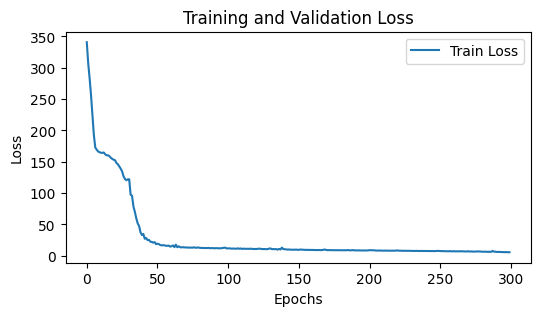

In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

In [ ]:
t_remainder_train_cdf = model.predict(input_data)
t_remainder_tain_pred = t_gev_dist.ppf(t_remainder_train_cdf)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


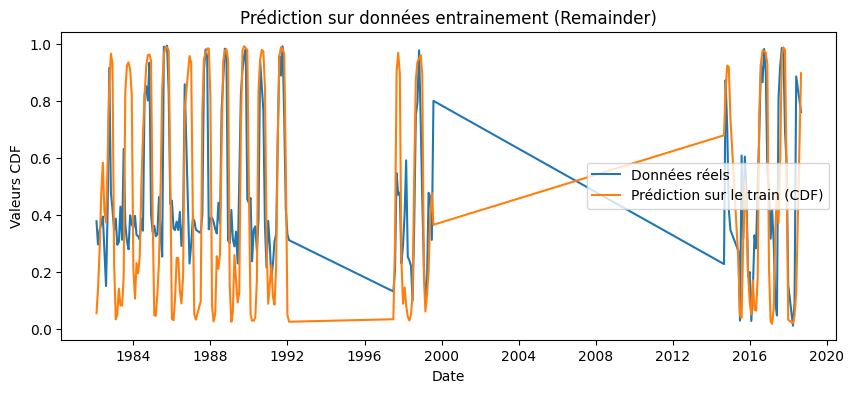

In [ ]:
# @title Train forcasting
plt.figure(figsize=(10, 4))
plt.plot(
    t_month_date_series[lag: num_train],

    output_data,
    label='Données réels'
)
plt.plot(
    t_month_date_series[lag: num_train],
    t_remainder_train_cdf,
    label='Prédiction sur le train (CDF)'
)
plt.xlabel('Date')
plt.ylabel('Valeurs CDF')
plt.legend()
plt.title('Prédiction sur données entrainement (Remainder)')
plt.show()

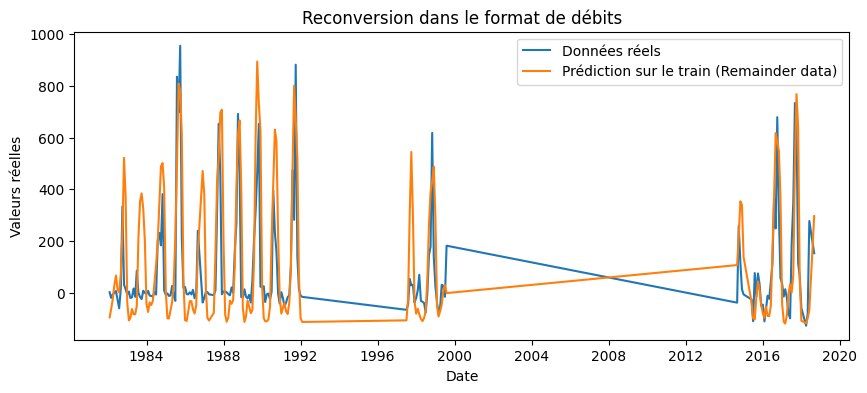

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(
    t_month_date_series[lag: num_train],
    t_remainder[lag: num_train],
    label='Données réels'
)
plt.plot(
    t_month_date_series[lag: num_train],
    t_remainder_tain_pred,
    label='Prédiction sur le train (Remainder data)'
)
plt.xlabel('Date')
plt.ylabel('Valeurs réelles')
plt.legend()
plt.title('Reconversion dans le format de débits')
plt.show()

In [ ]:
# On utilise les mêmes proportions et le même scaler que pour l'entraînement
test_frac = 0.85
n = features.shape[0] # Utilise le tableau des 4 variables
num_test = int(n * test_frac)

test_input = []
test_output = []

for i in range(num_test, n):
    # ICI : On prend les 4 colonnes et on aplatit (.flatten)
    # pour obtenir les 48 entrées attendues (12 lag * 4 variables)
    test_input.append(features[i - lag:i, :].flatten())

    # La cible reste la CDF du débit
    test_output.append([t_remainder_series_cdf[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

print(f'Test Input Data Shape: {test_input.shape}') # Doit être (X, 48)
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (37, 48)
Test Output Data Shape: (37, 1)


In [ ]:
#-------------------------------------------
#     LSTM / GRU Alternative
#-------------------------------------------
test_input = []
test_output = []

# Assure-toi que lag = 50 ici pour correspondre au train (146, 50, 4)
lag = 50

for i in range(num_test, n):
    # SURTOUT PAS de .flatten() pour un LSTM
    test_input.append(features[i - lag:i, :])
    test_output.append([t_remainder_series_cdf[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

# Le shape doit être (37, 50, 4)
print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (37, 50, 4)
Test Output Data Shape: (37, 1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step 


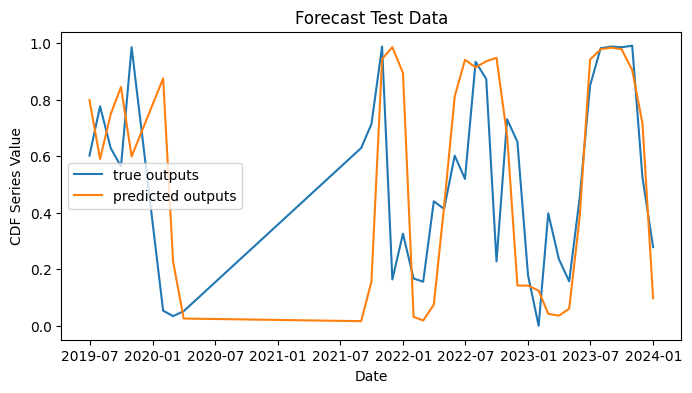

In [ ]:
t_remainder_test_cdf = model.predict(test_input)
t_remainder_test_prd = t_gev_dist.ppf(t_remainder_test_cdf)

plt.figure(figsize=(8, 4))
plt.plot(
    t_month_date_series[num_test:],
    test_output,
    label='true outputs'
)
plt.plot(
    t_month_date_series[num_test:],
    t_remainder_test_cdf,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('CDF Series Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

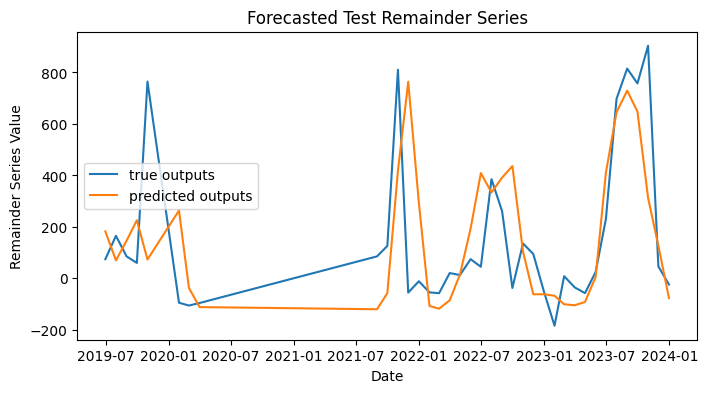

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(
    t_month_date_series[num_test:],
    t_remainder[num_test:],
    label='true outputs'
)
plt.plot(
    t_month_date_series[num_test:],
    t_remainder_test_prd,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('Remainder Series Value')
plt.legend()
plt.title('Forecasted Test Remainder Series')
plt.show()

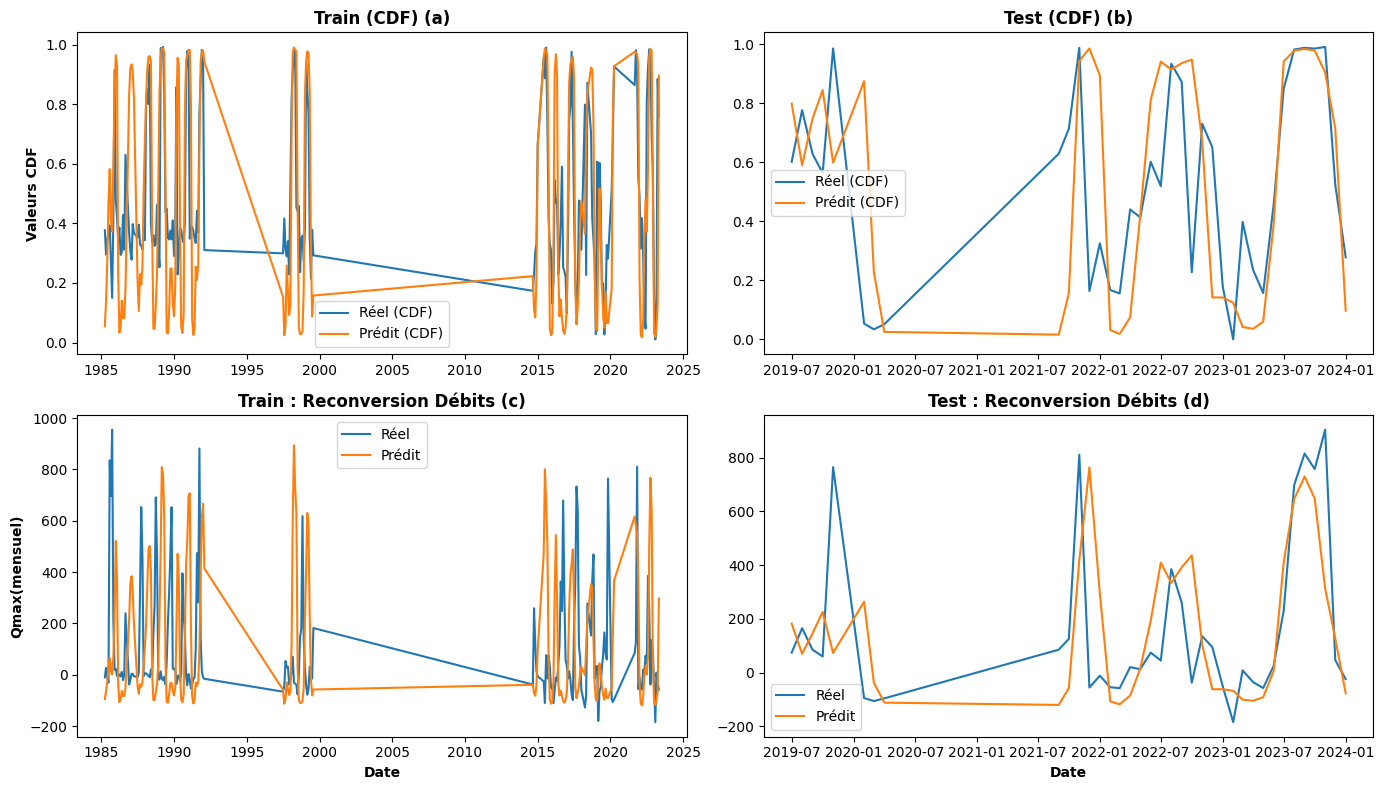

In [ ]:
import matplotlib.pyplot as plt

# Configuration des polices
title_p = {'fontsize': 12, 'fontweight': 'bold'}
label_p = {'fontsize': 10, 'fontweight': 'bold'}

# Création de la figure 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8),
                       gridspec_kw={'width_ratios': [2, 2]})

# Définition des longueurs pour éviter l'erreur de dimension
n_train = output_data.shape[0]
n_test = test_output.shape[0]

# ==========================================
# LIGNE 1 : ESPACE CDF (PROBABILITÉS)
# ==========================================

# TRAIN CDF (Utilise les n_train premiers éléments après le lag)
axes[0, 0].plot(t_month_date_series[lag:lag+n_train], output_data, label='Réel (CDF)')
axes[0, 0].plot(t_month_date_series[lag:lag+n_train], t_remainder_train_cdf, label='Prédit (CDF)')
axes[0, 0].set_title("Train (CDF) (a)", **title_p)
axes[0, 0].set_ylabel("Valeurs CDF", **label_p)
axes[0, 0].legend()

# TEST CDF (Utilise les n_test derniers éléments de la série de dates)
axes[0, 1].plot(t_month_date_series[-n_test:], test_output, label='Réel (CDF)')
axes[0, 1].plot(t_month_date_series[-n_test:], t_remainder_test_cdf, label='Prédit (CDF)')
axes[0, 1].set_title("Test (CDF) (b)", **title_p)
axes[0, 1].legend()

# ==========================================
# LIGNE 2 : ESPACE DÉBITS (RECONVERSION)
# ==========================================

# TRAIN REMAINDER
axes[1, 0].plot(t_month_date_series[lag:lag+n_train], t_remainder[lag:lag+n_train], label='Réel')
axes[1, 0].plot(t_month_date_series[lag:lag+n_train], t_remainder_tain_pred, label='Prédit')
axes[1, 0].set_title("Train : Reconversion Débits (c)", **title_p)
axes[1, 0].set_ylabel("Qmax(mensuel)", **label_p)
axes[1, 0].set_xlabel("Date", **label_p)
axes[1, 0].legend()

# TEST REMAINDER
axes[1, 1].plot(t_month_date_series[-n_test:], t_remainder[-n_test:], label='Réel')
axes[1, 1].plot(t_month_date_series[-n_test:], t_remainder_test_prd, label='Prédit')
axes[1, 1].set_title("Test : Reconversion Débits (d)", **title_p)
axes[1, 1].set_xlabel("Date", **label_p)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

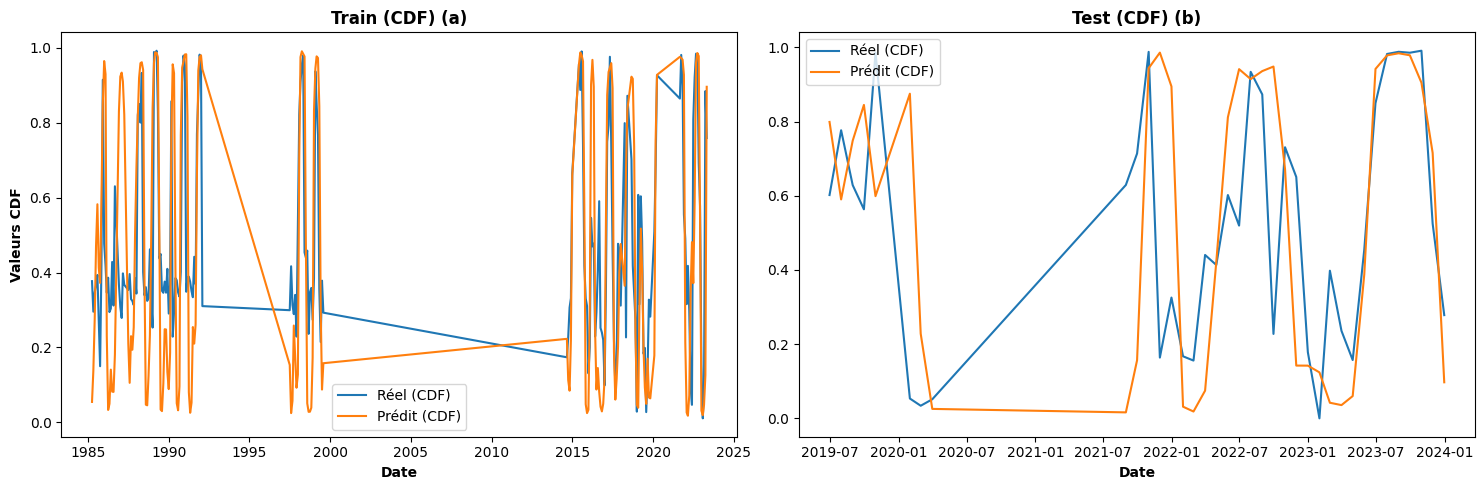

In [ ]:
# ==========================================
# FIGURE 1 : ESPACE CDF (PROBABILITÉS)
# ==========================================
fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(15, 5),
                         gridspec_kw={'width_ratios': [2, 2]})

# TRAIN CDF
axes1[0].plot(t_month_date_series[lag:lag+n_train], output_data, label='Réel (CDF)')
axes1[0].plot(t_month_date_series[lag:lag+n_train], t_remainder_train_cdf, label='Prédit (CDF)')
axes1[0].set_title("Train (CDF) (a)", **title_p)
axes1[0].set_ylabel("Valeurs CDF", **label_p)
axes1[0].set_xlabel("Date", **label_p)
axes1[0].legend()

# TEST CDF
axes1[1].plot(t_month_date_series[-n_test:], test_output, label='Réel (CDF)')
axes1[1].plot(t_month_date_series[-n_test:], t_remainder_test_cdf, label='Prédit (CDF)')
axes1[1].set_title("Test (CDF) (b)", **title_p)
axes1[1].set_xlabel("Date", **label_p)
axes1[1].legend()

plt.tight_layout()
plt.show()

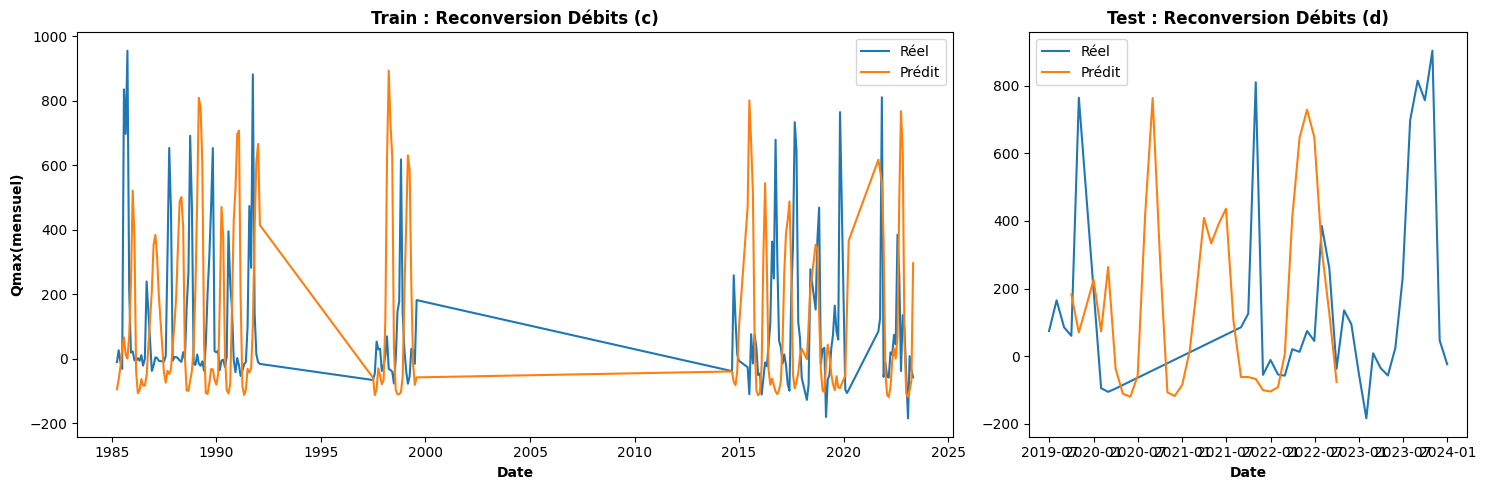

In [ ]:
# ==========================================
# FIGURE 2 : ESPACE DÉBITS (RECONVERSION)
# ==========================================
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(15, 5),
                         gridspec_kw={'width_ratios': [2, 1]})

# TRAIN REMAINDER
axes2[0].plot(t_month_date_series[lag:lag+n_train], t_remainder[lag:lag+n_train], label='Réel')
axes2[0].plot(t_month_date_series[lag:lag+n_train], t_remainder_tain_pred, label='Prédit')
axes2[0].set_title("Train : Reconversion Débits (c)", **title_p)
axes2[0].set_ylabel("Qmax(mensuel)", **label_p)
axes2[0].set_xlabel("Date", **label_p)
axes2[0].legend()

# TEST REMAINDER
axes2[1].plot(t_month_date_series[-n_test:], t_remainder[-n_test:], label='Réel')
axes2[1].plot(d_month_date_series[-n_test:], t_remainder_test_prd, label='Prédit')
axes2[1].set_title("Test : Reconversion Débits (d)", **title_p)
axes2[1].set_xlabel("Date", **label_p)
axes2[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# @title Trend Forcasting

# @title Trend Forcasting
lag = 12

model_trend = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation=None)
])

model_trend.build(input_shape=(None, lag))
model_trend.compile(
    optimizer=tf.optimizers.Adam(
        tf.optimizers.schedules.ExponentialDecay(
            0.01, 50, 0.9
        )
    ),
    loss=tf.losses.MeanSquaredError()
)

train_frac = 0.8
# n = Ttou_month_max.dropna
n = d_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(t_trend[i - lag:i])
    output_data.append([t_trend[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

print(f'Input Data Shape: {input_data.shape}')
print(f'Output Data Shape: {output_data.shape}')

Input Data Shape: (384, 12)
Output Data Shape: (384, 1)


/tmp/ipykernel_49477/3661804856.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_data.append([t_trend[i]])


In [ ]:
history = model_trend.fit(input_data,
                          output_data,
                          verbose = 0,
                          # callbacks = ,
                          epochs=100)

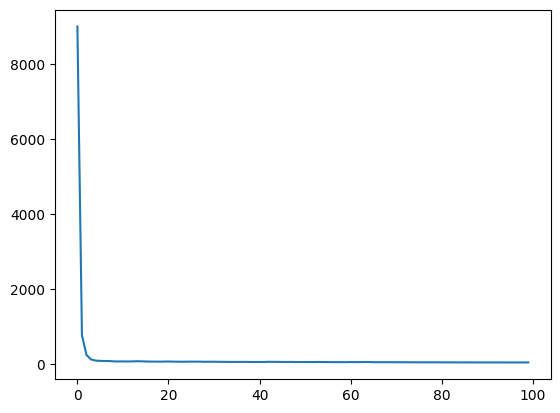

In [ ]:
plt.plot(history.history['loss'])

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


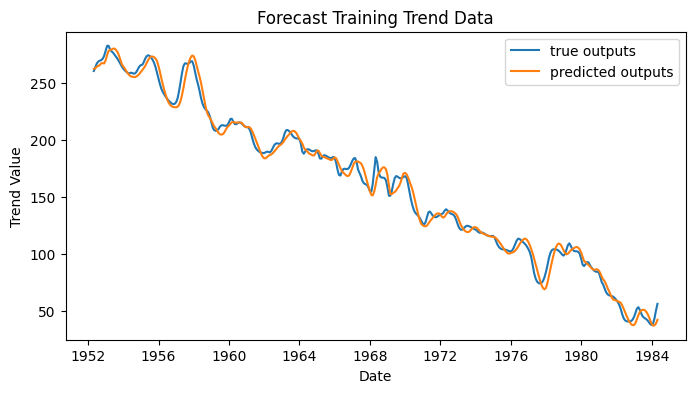

In [ ]:
# @title Train trend Forcastiing
t_trend_train_pred = model_trend.predict(input_data)

plt.figure(figsize=(8, 4))
plt.plot(
    t_month_date_series[lag: num_train],
    output_data,
    label='true outputs'
)
plt.plot(
    t_month_date_series[lag: num_train],
    t_trend_train_pred,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('Trend Value')
plt.legend()
plt.title('Forecast Training Trend Data')
plt.show()

In [ ]:
test_frac = 0.85
n = t_remainder_series_cdf.shape[0]
num_test = int(n * test_frac)

In [ ]:
# @title Test Trend Forcast
test_input = []
test_output = []

for i in range(num_test, n):
    test_input.append(t_trend[i - lag:i])
    test_output.append([t_trend[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (90, 12)
Test Output Data Shape: (90, 1)


/tmp/ipykernel_49477/776504295.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_output.append([t_trend[i]])


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


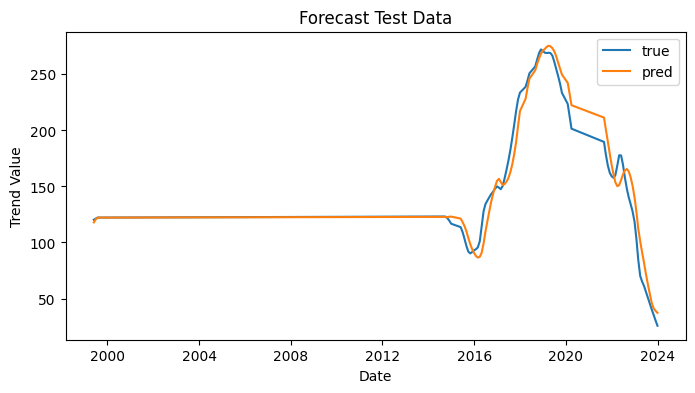

In [ ]:
# @title Prédiction de la tedence sur les données de teste
t_trend_test_pred = model_trend.predict(test_input)

plt.figure(figsize=(8, 4))

plt.plot(
    t_month_date_series[num_test:],
    test_output,
    label='true'
)
plt.plot(
    t_month_date_series[num_test:],
    t_trend_test_pred,
    label='pred'
)
plt.xlabel('Date')
plt.ylabel('Trend Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

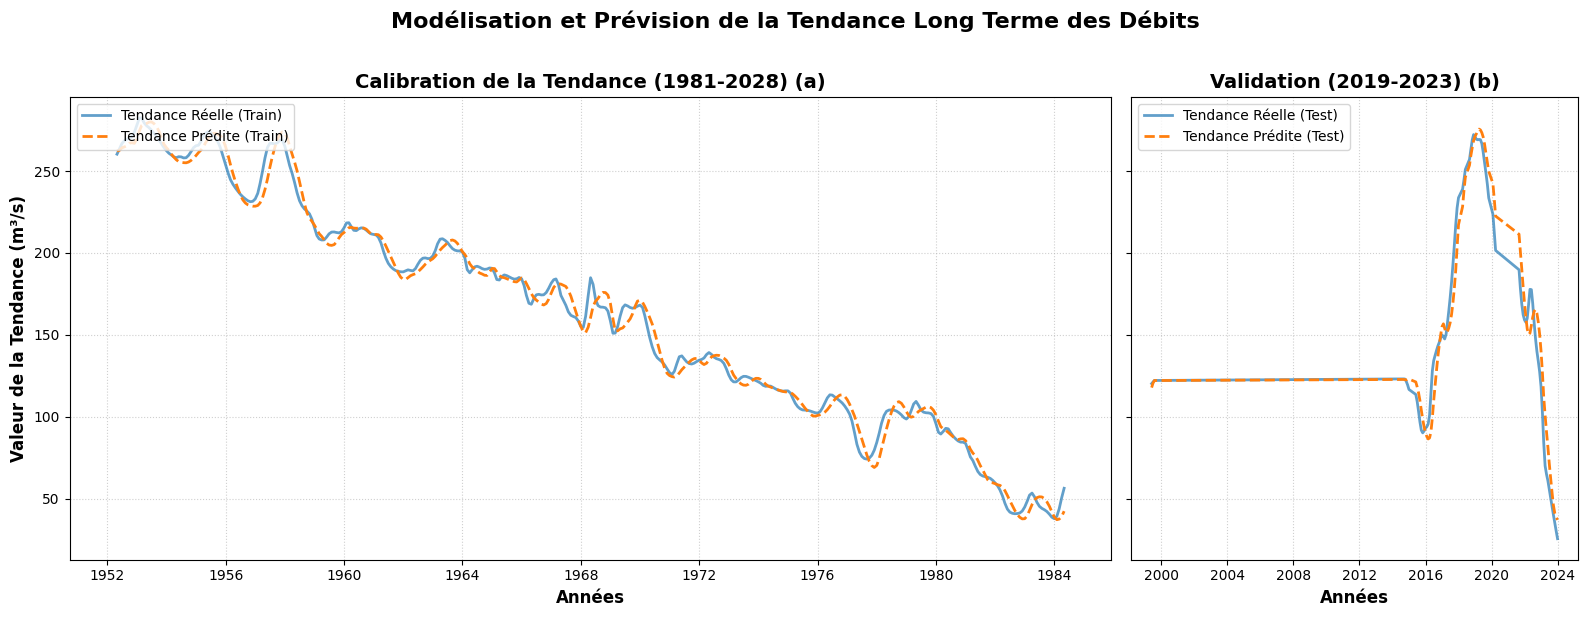

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Configuration des polices pour un rendu académique
title_p = {'fontsize': 14, 'fontweight': 'bold'}
label_p = {'fontsize': 12, 'fontweight': 'bold'}

# Création de la figure
fig = plt.figure(figsize=(16, 6))

# --- SOLUTION POUR LE RATIO 70/30 ---
# On utilise GridSpec pour définir des colonnes de largeurs inégales
# width_ratios=[7, 3] donne 70% à la première colonne et 30% à la deuxième
gs = gridspec.GridSpec(1, 2, width_ratios=[7, 3])

# Création des sous-graphiques (subplots)
ax_train = fig.add_subplot(gs[0])
ax_test = fig.add_subplot(gs[1], sharey=ax_train) # Partage de l'axe Y pour la comparaison

# ==========================================
# PARTIE 1 : ENTRAÎNEMENT (70% de largeur)
# ==========================================
ax_train.plot(
    t_month_date_series[lag: num_train],
    output_data,
    label='Tendance Réelle (Train)',
    color='#1f77b4', # Bleu standard
    alpha=0.7,
    linewidth=2
)
ax_train.plot(
    t_month_date_series[lag: num_train],
    t_trend_train_pred,
    label='Tendance Prédite (Train)',
    color='#ff7f0e', # Orange standard
    linestyle='--',
    linewidth=2
)

ax_train.set_title('Calibration de la Tendance (1981-2028) (a)', **title_p)
ax_train.set_xlabel('Années', **label_p)
ax_train.set_ylabel('Valeur de la Tendance (m³/s)', **label_p)
ax_train.legend(loc='upper left', fontsize=10)
ax_train.grid(True, linestyle=':', alpha=0.6)

# ==========================================
# PARTIE 2 : TEST (30% de largeur)
# ==========================================
ax_test.plot(
    t_month_date_series[num_test:],
    test_output,
    label='Tendance Réelle (Test)',
    color='#1f77b4',
    alpha=0.7,
    linewidth=2
)
ax_test.plot(
    t_month_date_series[num_test:],
    t_trend_test_pred,
    label='Tendance Prédite (Test)',
    color='#ff7f0e',
    linestyle='--',
    linewidth=2
)

ax_test.set_title('Validation (2019-2023) (b)', **title_p)
ax_test.set_xlabel('Années', **label_p)
# On cache le label Y du test car il est partagé avec le train (sharey=True)
plt.setp(ax_test.get_yticklabels(), visible=False)
ax_test.legend(loc='upper left', fontsize=10)
ax_test.grid(True, linestyle=':', alpha=0.6)

# --- TITRE GÉNÉRAL DE LA FIGURE ---
fig.suptitle("Modélisation et Prévision de la Tendance Long Terme des Débits",
             fontsize=16, fontweight='bold', y=1.02)

# Ajustement automatique des espaces
plt.tight_layout()
plt.show()

In [ ]:
# @title Saisonality forcasting
t_seasonality_train = t_seasonal[:num_train][lag:]

season_values = d_seasonal[:num_train][-12:]
t_seasonality_test = np.zeros((n - num_test, 1))

for i in range(n - num_test):
    t_seasonality_test[i] = season_values[i % 12]

/tmp/ipykernel_49477/3523493163.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  t_seasonality_test[i] = season_values[i % 12]


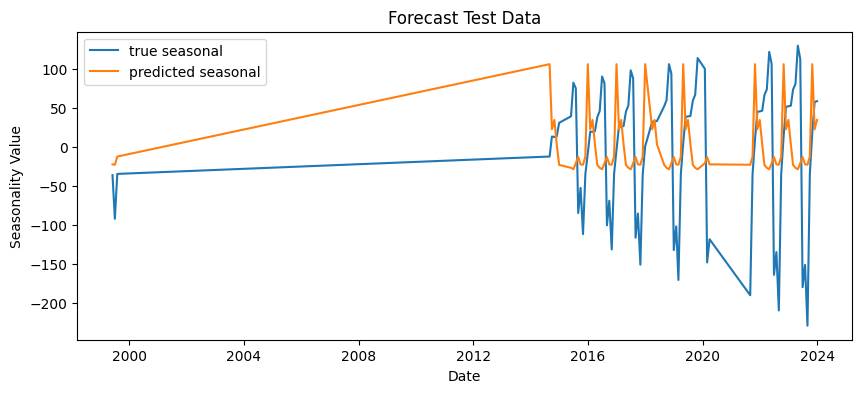

In [ ]:
# @title Prédiction de la saisonnalité sur les données de teste
plt.figure(figsize=(10, 4))

plt.plot(
    t_month_date_series[num_test:],
    t_seasonal[num_test:],
    label='true seasonal'
)
plt.plot(
    t_month_date_series[num_test:],
    t_seasonality_test,
    label='predicted seasonal'
)
plt.xlabel('Date')
plt.ylabel('Seasonality Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

In [ ]:
# @title Maximum deschage Forcast
print(t_remainder_tain_pred.shape, t_trend_train_pred.shape, t_seasonality_train.shape)
print(t_remainder_test_prd.shape, t_trend_test_pred.shape, t_seasonality_test.shape)

(384, 1) (384, 1) (384,)
(72, 1) (90, 1) (90, 1)


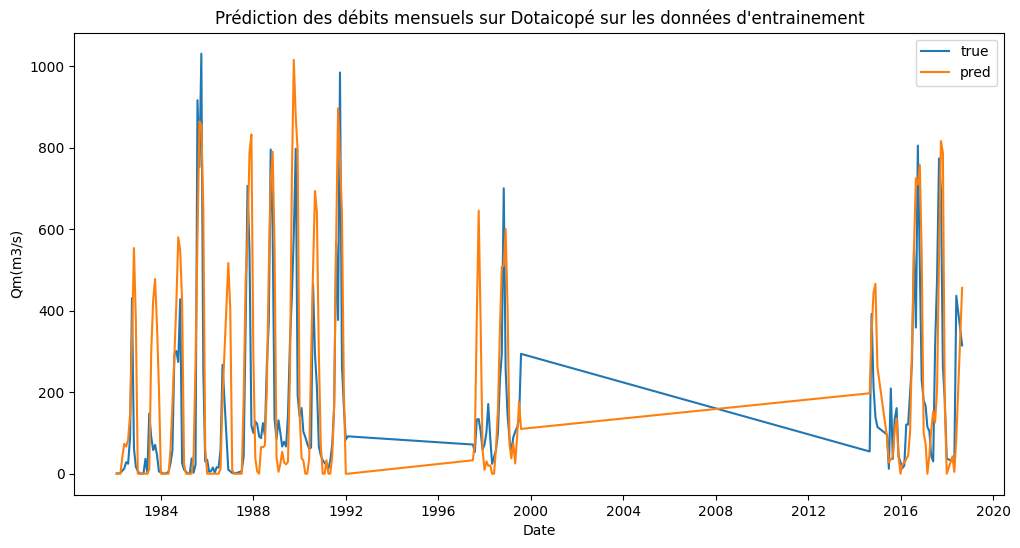

In [ ]:
# @title Prédiction des débits mensuels sur les données d'entrainement
pred_train = np.maximum(t_remainder_tain_pred.flatten() + t_trend_train_pred.flatten() + t_seasonality_train, 0)
# pred_train = np.maximum(t_remainder_tain_pred.flatten() + t_trend_train_pred.flatten()[:181] + t_seasonality_train[:181], 0)
true_train = Ttou_month_max[:num_train][lag:]

plt.figure(figsize=(12, 6))

plt.plot(
    t_month_date_series[lag: num_train],
    true_train,
    label='true'
)

plt.plot(
    t_month_date_series[lag: num_train],
    pred_train,
    label='pred'
)

plt.title("Prédiction des débits mensuels sur Dotaicopé sur les données d'entrainement")
plt.xlabel('Date')
plt.ylabel('Qm(m3/s)')
plt.legend()
plt.show()

In [ ]:
# @title Prédiction des débits mensuels sur les données de teste
pred_test = np.maximum(t_remainder_test_prd + t_trend_test_pred + t_seasonality_test, 0)
true_test = Ttou_month_max[num_test:]

plt.figure(figsize=(8, 4))

plt.plot(
    t_month_date_series[num_test:],
    true_test,
    label='true'
)
plt.plot(
    t_month_date_series[num_test:],
    pred_test,
    label='pred'
)
plt.title("Prédiction des débits mensuels sur Dotaicopé sur les données de teste")
plt.xlabel('Date')
plt.ylabel('Qm(m3/s)')
plt.legend()
plt.show()

ValueError: operands could not be broadcast together with shapes (72,1) (90,1) 

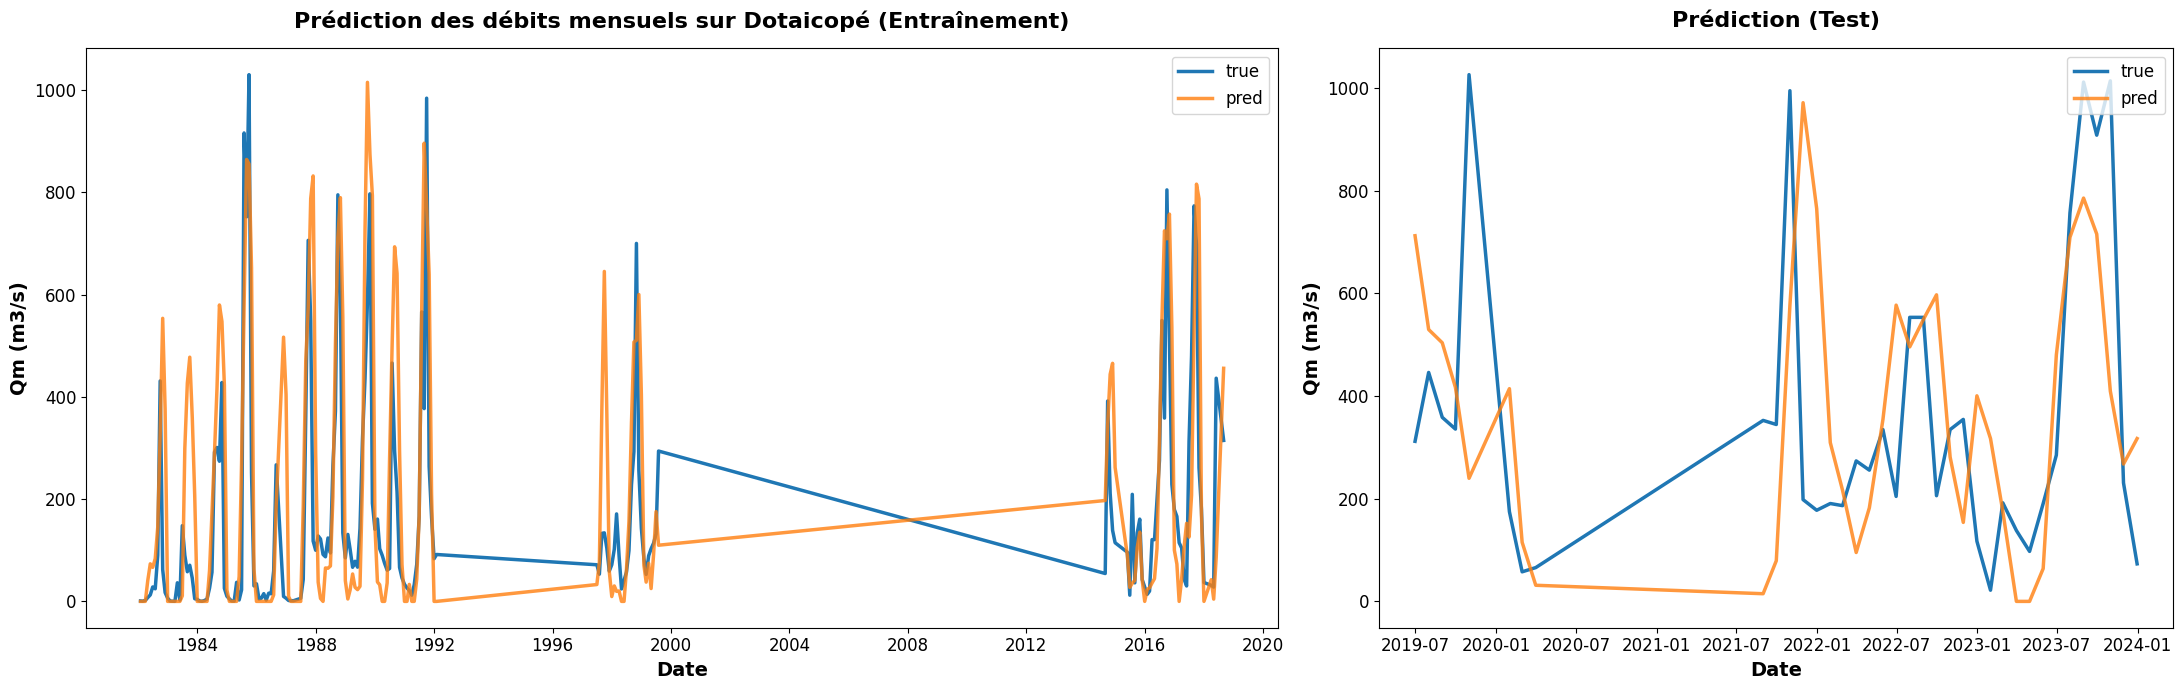

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Calcul des données ---
pred_train = np.maximum(t_remainder_tain_pred.flatten() + t_trend_train_pred.flatten() + t_seasonality_train, 0)
# pred_train = np.maximum(t_remainder_tain_pred.flatten()[:146] + t_trend_train_pred.flatten() + t_seasonality_train, 0)
true_train = Ttou_month_max[:num_train][lag:]

pred_test = np.maximum(t_remainder_test_prd + t_trend_test_pred + t_seasonality_test, 0)
true_test = Ttou_month_max[num_test:]

# --- Configuration de la figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), gridspec_kw={'width_ratios': [3, 2]})

# Paramètres de style communs
font_title = {'weight': 'bold', 'size': 16}
font_label = {'weight': 'bold', 'size': 14}

# --- Graphique 1 : Entraînement ---
ax1.plot(t_month_date_series[lag: num_train], true_train, label='true', linewidth=2.5)
ax1.plot(t_month_date_series[lag: num_train], pred_train, label='pred', linewidth=2.5, alpha=0.8)

ax1.set_title("Prédiction des débits mensuels sur Dotaicopé (Entraînement)", fontdict=font_title, pad=15)
ax1.set_xlabel('Date', fontdict=font_label)
ax1.set_ylabel('Qm (m3/s)', fontdict=font_label)
ax1.legend(fontsize=12, loc='upper right')
ax1.tick_params(axis='both', which='major', labelsize=12) # Taille des chiffres sur les axes

# --- Graphique 2 : Test ---
ax2.plot(t_month_date_series[num_test:], true_test, label='true', linewidth=2.5)
ax2.plot(t_month_date_series[num_test:], pred_test, label='pred', linewidth=2.5, alpha=0.8)

ax2.set_title("Prédiction (Test)", fontdict=font_title, pad=15)
ax2.set_xlabel('Date', fontdict=font_label)
ax2.set_ylabel('Qm (m3/s)', fontdict=font_label)
ax2.legend(fontsize=12, loc='upper right')
ax2.tick_params(axis='both', which='major', labelsize=12)

# Ajustement final
plt.tight_layout()

# Pour un rendu très net dans un notebook ou lors de l'enregistrement
# plt.savefig('prediction_debit.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score, f1_score

def get_hydrology_report(y_true, y_pred, label="Modèle", threshold_percentile=75):
    """
    Calcule et affiche un rapport complet de métriques hydrologiques.
    """
    # Nettoyage des données (suppression des NaNs éventuels)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    true = np.array(y_true)[mask]
    pred = np.array(y_pred)[mask]

    # --- 1. Métriques de Régression (Erreur Globale) ---
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)

    # --- 2. Efficacité Hydrologique (NSE & KGE) ---
    # Nash-Sutcliffe Efficiency
    nse = 1 - (np.sum((true - pred)**2) / np.sum((true - np.mean(true))**2))

    # Kling-Gupta Efficiency (KGE 2009)
    r = np.corrcoef(true, pred)[0, 1]
    alpha = np.std(pred) / np.std(true)
    beta = np.mean(pred) / np.mean(true)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    # --- 3. Métriques de Classification (Extrêmes / POT) ---
    threshold = np.percentile(true, threshold_percentile)
    true_bin = (true >= threshold).astype(int)
    pred_bin = (pred >= threshold).astype(int)

    prec = precision_score(true_bin, pred_bin, zero_division=0)
    rec = recall_score(true_bin, pred_bin, zero_division=0)
    f1 = f1_score(true_bin, pred_bin, zero_division=0)

    # Affichage structuré
    print(f"--- Rapport de Performance : {label} ---")
    print(f"Seuil ({threshold_percentile}ème perc.) : {threshold:.4f}")
    print(f"{'RMSE:':<15} {rmse:.4f}")
    print(f"{'MAE:':<15} {mae:.4f}")
    print(f"{'NSE:':<15} {nse:.4f}")
    print(f"{'KGE:':<15} {kge:.4f}")
    print(f"{'Précision:':<15} {prec:.4f}")
    print(f"{'Rappel:':<15} {rec:.4f}")
    print(f"{'F1-Score:':<15} {f1:.4f}")
    print("-" * 40)

    return {
        "rmse": rmse, "mae": mae, "nse": nse, "kge": kge,
        "precision": prec, "recall": rec, "f1": f1
    }

In [ ]:
# @title Model Sequentiel
results_rem = get_hydrology_report(
    t_remainder[num_test:],
    t_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 165.1102
RMSE:           259.9156
MAE:            182.1166
NSE:            0.2489
KGE:            0.1568
Précision:      0.5556
Rappel:         0.5000
F1-Score:       0.5263
----------------------------------------


In [ ]:
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 358.4760
RMSE:           323.4196
MAE:            246.0307
NSE:            -0.2514
KGE:            0.3670
Précision:      0.4500
Rappel:         0.9000
F1-Score:       0.6000
----------------------------------------


In [ ]:
# @title Model LSTM

results_rem = get_hydrology_report(
    t_remainder[num_test:],
    t_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 165.1102
RMSE:           259.9156
MAE:            182.1166
NSE:            0.2489
KGE:            0.1568
Précision:      0.5556
Rappel:         0.5000
F1-Score:       0.5263
----------------------------------------


In [ ]:
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 358.4760
RMSE:           300.7435
MAE:            232.9737
NSE:            -0.0821
KGE:            0.2003
Précision:      0.4286
Rappel:         0.6000
F1-Score:       0.5000
----------------------------------------


In [ ]:
# @title Model GRU

# @title Model LSTM

results_rem = get_hydrology_report(
    t_remainder[num_test:],
    t_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 165.1102
RMSE:           261.9206
MAE:            176.4996
NSE:            0.2372
KGE:            0.5486
Précision:      0.5000
Rappel:         0.8000
F1-Score:       0.6154
----------------------------------------


In [ ]:
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 358.4760
RMSE:           300.2271
MAE:            221.9795
NSE:            -0.0784
KGE:            0.3720
Précision:      0.5000
Rappel:         0.9000
F1-Score:       0.6429
----------------------------------------


In [ ]:
# @title Model LSTM-GRU

# @title Model GRU

# @title Model LSTM

results_rem = get_hydrology_report(
    t_remainder[num_test:],
    t_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 165.1102
RMSE:           319.9867
MAE:            214.5352
NSE:            -0.1385
KGE:            -0.2295
Précision:      0.2000
Rappel:         0.1000
F1-Score:       0.1333
----------------------------------------


In [ ]:
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 358.4760
RMSE:           362.6081
MAE:            272.0322
NSE:            -0.5730
KGE:            -0.2264
Précision:      0.1818
Rappel:         0.2000
F1-Score:       0.1905
----------------------------------------


--------
Models univarié

In [193]:
# @title Decomposition STL
def stl_decompose(series):

    stl = STL(
        series,
        period=12,
        seasonal=101,
        robust=True
    )

    res = stl.fit()

    return res.trend, res.seasonal, res.resid

# STL
# t_trend, t_seasonal, t_remainder = stl_decompose(Ttou_month_max['Qj'])
# d_trend, d_seasonal, d_remainder = stl_decompose(Dtkp_month_max['Qj'])
# k_trend, k_seasonal, k_remainder = stl_decompose(Klkp_month_max['Qj'])

import numpy as np

# On applique le log sur les séries originales avant STL (ou sur les residus, mais le mieux est avant)
t_log = np.log1p(Ttou_month_max['Qj'])
d_log = np.log1p(Dtkp_month_max['Qj'])
k_log = np.log1p(Klkp_month_max['Qj'])

# Refais ta décomposition STL sur ces versions log
t_trend, t_seasonal, t_remainder = stl_decompose(t_log)
d_trend, d_seasonal, d_remainder = stl_decompose(d_log)
k_trend, k_seasonal, k_remainder = stl_decompose(k_log)

from scipy.stats import genextreme

# Fit GEV

t_c, t_loc, t_scale = genextreme.fit(t_remainder.values)
d_c, d_loc, d_scale = genextreme.fit(d_remainder.values)
k_c, k_loc, k_scale = genextreme.fit(k_remainder.values)

t_trend, t_seasonal, t_remainder = stl_decompose(Ttou_month_max['Qj'])
d_trend, d_seasonal, d_remainder = stl_decompose(Dtkp_month_max['Qj'])
k_trend, k_seasonal, k_remainder = stl_decompose(Klkp_month_max['Qj'])

# Fit GEV

t_c, t_loc, t_scale = genextreme.fit(t_remainder.values, f0=-t_c)
d_c, d_loc, d_scale = genextreme.fit(d_remainder.values)
k_c, k_loc, k_scale = genextreme.fit(k_remainder.values, f0=-k_c)

#Distributions
t_gev_dist = genextreme(t_c, loc = t_loc, scale = t_scale)
d_gev_dist = genextreme(d_c, loc = d_loc, scale = d_scale)
k_gev_dist = genextreme(k_c, loc = k_loc, scale = k_scale)

# Transform to probability space
t_remainder_series_cdf = t_gev_dist.cdf(t_remainder)
d_remainder_series_cdf = d_gev_dist.cdf(d_remainder)
k_remainder_series_cdf = k_gev_dist.cdf(k_remainder)

In [196]:
t_remainder.shape

(598,)

In [ ]:
def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 40)  # Adjust the scale factor
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 10)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def tail_weighted_mse(y_true, y_pred):
    # On utilise une exponentielle directe sur y_true
    # Plus y_true approche de 1, plus le poids explose
    weights = tf.exp(y_true * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    dist_from_center = tf.abs(y_true - 0.5)
    # Réduis de 8.0 à 3.0 ou 4.0 pour stabiliser l'apprentissage
    weights = tf.exp(dist_from_center * 40)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

In [ ]:
# @title Modèle séquentiel
from sklearn.preprocessing import MinMaxScaler
import numpy as np

import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error

lag = 12

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

# 1. On "étire" les probabilités CDF sur toute la plage [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
# reshape car le scaler attend une matrice 2D
t_cdf_stretched = scaler.fit_transform(t_remainder_series_cdf.reshape(-1, 1)).flatten()

train_frac = 0.85

n = t_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

# 2. Tu recrées tes données d'entraînement avec t_cdf_stretched

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(t_cdf_stretched[i - lag:i])
    output_data.append([t_cdf_stretched[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

model.build(input_shape=(None, lag))

# 3. Entraîne ton modèle (avec MSE standard pour commencer)
model.compile(
    optimizer='adam',
    # loss=tail_weighted_mse
    # loss='mse',
    loss=dual_tail_weighted_mse
)

In [ ]:
# @title Modele LSTM
# Nouveau modèle LSTM

lag = 12

model = tf.keras.Sequential([
    # On précise (lag, 1) car chaque pas de temps a 1 valeur
    tf.keras.layers.LSTM(32, input_shape=(lag, 1), return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Garde sigmoid si tu es en espace [0,1]
])

model.compile(optimizer='adam',
              # loss='mse',
              loss=dual_tail_weighted_mse
              )

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(t_remainder_series_cdf[i - lag:i])
    output_data.append([t_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

# --- LA MODIFICATION CRUCIALE POUR LE LSTM ---
# On passe de (Echantillons, 12) à (Echantillons, 12, 1)
input_data = input_data.reshape((input_data.shape[0], lag, 1))
output_data = np.array(output_data)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [147]:
# @title Modèle GRU
lag = 12

def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 10)  # Adjust the scale factor
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 10)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

# def tail_weighted_mse(y_true, y_pred):
#     # On utilise une exponentielle directe sur y_true
#     # Plus y_true approche de 1, plus le poids explose
#     weights = tf.exp(y_true * 20)
#     return tf.reduce_mean(weights * tf.square(y_true - y_pred))

model = tf.keras.Sequential([
    # Le shape reste (lag, 1) pour l'univarié ou (lag, 4) pour le multivarié
    tf.keras.layers.GRU(32, input_shape=(lag, 1), return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Car tu prédis une CDF (0 à 1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer = optimizer,
    # optimizer='adam',
    # loss='mse',
    loss = tail_weighted_mse,
    # loss = dual_tail_weighted_mse
)

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(t_remainder_series_cdf[i - lag:i])
    output_data.append([t_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

# Rappel de la transformation nécessaire avant le fit()
input_data = input_data.reshape((input_data.shape[0], lag, 1))
output_data = output_data

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# @title Modele LSTM - GRU
import numpy as np
import tensorflow as tf

lag = 24

# 1. Préparation des données (Identique à tes modèles précédents)
train_frac = 0.80
n = d_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(d_remainder_series_cdf[i - lag:i])
    output_data.append([d_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

# La modification pour le format 3D (comme pour tes LSTM/GRU)
input_data = input_data.reshape((input_data.shape[0], lag, 1))

# 2. Architecture Hybride (Entrée unifiée)
input_seq = tf.keras.Input(shape=(lag, 1))

# Branche LSTM
lstm_out = tf.keras.layers.LSTM(64, return_sequences=False)(input_seq)
y_main = tf.keras.layers.Dense(1)(lstm_out)

# Branche GRU
gru_out = tf.keras.layers.GRU(32, return_sequences=False)(input_seq)
y_correction = tf.keras.layers.Dense(1)(gru_out)

# Fusion par addition
final_output = tf.keras.layers.Add()([y_main, y_correction])

model = tf.keras.Model(inputs=input_seq, outputs=final_output)

# 3. Compilation et Entraînement
model.compile(optimizer='adam', loss='mse')

In [148]:
hist = model.fit(input_data,
                 output_data,
                 epochs=300,
                 batch_size=16,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=10)],
                 verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


Text(0, 0.5, 'Loss')

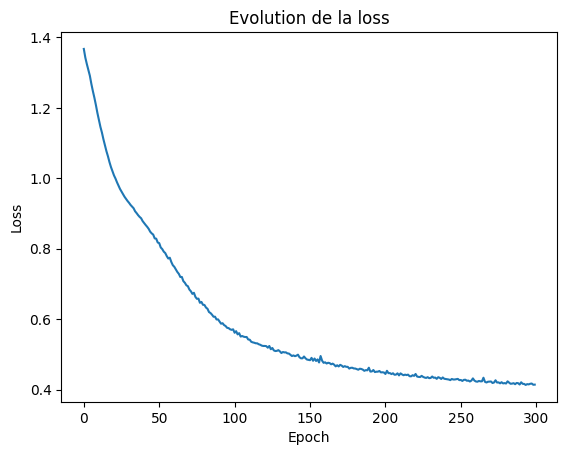

In [149]:
plt.plot(hist.history['loss'])
plt.title('Evolution de la loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [150]:
t_remainder_train_cdf = model.predict(input_data)

# 1. Inversion du scaling (pour repasser de [0,1] aux probabilités réelles)
t_remainder_train_cdf_original = scaler.inverse_transform(t_remainder_train_cdf)

# 2. Transformation inverse GEV (pour repasser des probabilités aux débits/résidus)
t_remainder_train_pred = t_gev_dist.ppf(t_remainder_train_cdf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


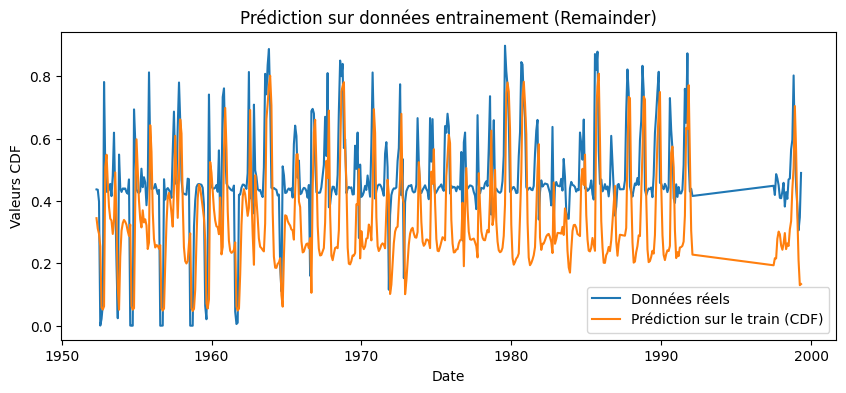

In [151]:
# @title Train forcasting
plt.figure(figsize=(10, 4))
plt.plot(
    t_month_date_series[lag: num_train],

    output_data,
    label='Données réels'
)
plt.plot(
    t_month_date_series[lag: num_train],
    t_remainder_train_cdf_original,
    label='Prédiction sur le train (CDF)'
)
plt.xlabel('Date')
plt.ylabel('Valeurs CDF')
plt.legend()
plt.title('Prédiction sur données entrainement (Remainder)')
plt.show()

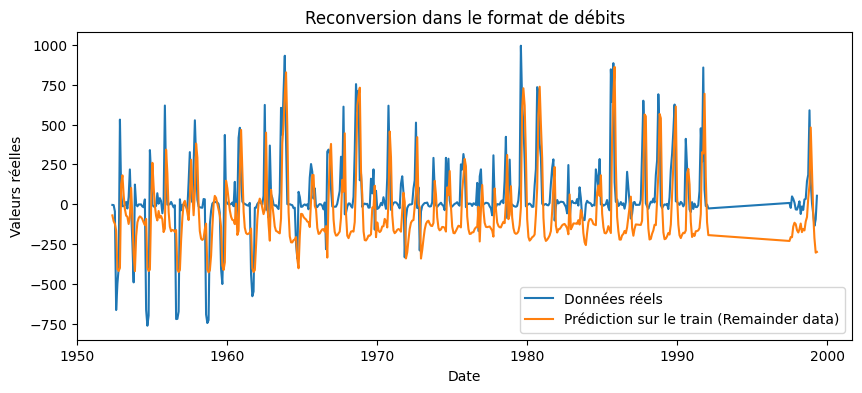

In [152]:
plt.figure(figsize=(10, 4))
plt.plot(
    t_month_date_series[lag: num_train],
    t_remainder[lag: num_train],
    label='Données réels'
)
plt.plot(
    t_month_date_series[lag: num_train],
    t_remainder_train_pred,
    label='Prédiction sur le train (Remainder data)'
)
plt.xlabel('Date')
plt.ylabel('Valeurs réelles')
plt.legend()
plt.title('Reconversion dans le format de débits')
plt.show()

In [153]:
test_frac = 0.88
n = t_remainder_series_cdf.shape[0]
num_test = int(n * test_frac)

In [154]:
test_input = []
test_output = []

for i in range(num_test, n):
    test_input.append(t_remainder_series_cdf[i - lag:i])
    test_output.append([t_remainder_series_cdf[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (72, 12)
Test Output Data Shape: (72, 1)


In [155]:
#---------------------------
#    LSTM - GRU
#---------------------------

test_input = []
test_output = []

for i in range(num_test, n):
    test_input.append(t_remainder_series_cdf[i - lag:i])
    test_output.append([t_remainder_series_cdf[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

# --- L'AJUSTEMENT POUR LE MODÈLE HYBRIDE ---
# On ajoute la dimension 1 pour que le shape soit (échantillons, lag, 1)
test_input = test_input.reshape((test_input.shape[0], lag, 1))

print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

# Maintenant la prédiction fonctionnera parfaitement
t_remainder_test_cdf = model.predict(test_input)

Test Input Data Shape: (72, 12, 1)
Test Output Data Shape: (72, 1)
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


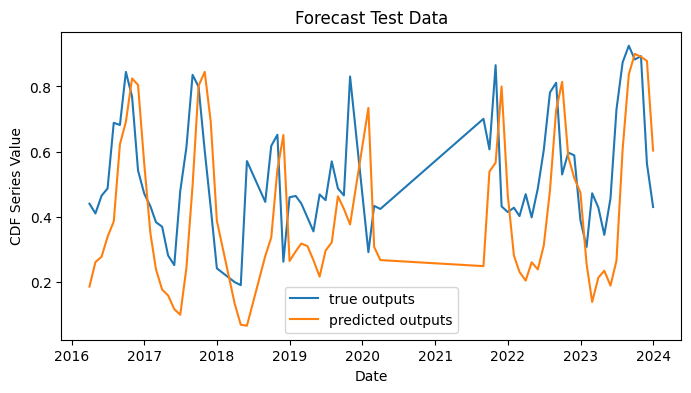

In [156]:
t_remainder_test_cdf = model.predict(test_input)
t_remainder_test_prd = t_gev_dist.ppf(t_remainder_test_cdf)

plt.figure(figsize=(8, 4))
plt.plot(
    t_month_date_series[num_test:],
    test_output,
    label='true outputs'
)
plt.plot(
    t_month_date_series[num_test:],
    t_remainder_test_cdf,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('CDF Series Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

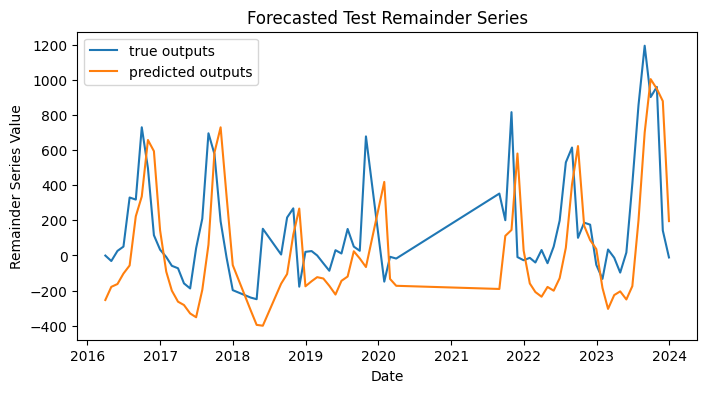

In [157]:
plt.figure(figsize=(8, 4))

plt.plot(
    t_month_date_series[num_test:],
    t_remainder[num_test:],
    label='true outputs'
)
plt.plot(
    t_month_date_series[num_test:],
    t_remainder_test_prd,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('Remainder Series Value')
plt.legend()
plt.title('Forecasted Test Remainder Series')
plt.show()

In [158]:
# import matplotlib.pyplot as plt

# # Configuration des polices
# title_p = {'fontsize': 12, 'fontweight': 'bold'}
# label_p = {'fontsize': 10, 'fontweight': 'bold'}

# # FIGURE 1 : ESPACE CDF (PROBABILITÉS)
# fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# # TRAIN CDF
# axes1[0].plot(t_month_date_series[lag:lag+n_train], output_data, label='Réel (CDF)', alpha=0.7)
# axes1[0].plot(t_month_date_series[lag:lag+n_train], t_remainder_train_cdf, label='Prédit (CDF)', linestyle='--')
# axes1[0].set_title("Entraînement : Espace des Probabilités (CDF) (a)", **title_p)
# axes1[0].set_ylabel("Valeurs CDF [0, 1]", **label_p)
# axes1[0].set_xlabel("Date", **label_p)
# axes1[0].legend()

# # TEST CDF
# axes1[1].plot(t_month_date_series[-n_test:], test_output, label='Réel (CDF)', alpha=0.7)
# axes1[1].plot(t_month_date_series[-n_test:], t_remainder_test_cdf, label='Prédit (CDF)', linestyle='--')
# axes1[1].set_title("Test : Espace des Probabilités (CDF) (b)", **title_p)
# axes1[1].set_xlabel("Date", **label_p)
# axes1[1].legend()

# plt.tight_layout()
# plt.show()

In [159]:
# # FIGURE 2 : ESPACE DÉBITS (RECONVERSION)
# fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# # TRAIN DÉBITS
# axes2[0].plot(t_month_date_series[lag:lag+n_train], t_remainder[lag:lag+n_train], label='Réel', color='blue', alpha=0.6)
# axes2[0].plot(t_month_date_series[lag:lag+n_train], t_remainder_train_pred, label='Prédit', color='orange', linestyle='--')
# axes2[0].set_title("Entraînement : Reconversion en Débits (c)", **title_p)
# axes2[0].set_ylabel("Qmax mensuel (m³/s)", **label_p)
# axes2[0].set_xlabel("Date", **label_p)
# axes2[0].legend()

# # TEST DÉBITS
# axes2[1].plot(t_month_date_series[-n_test:], t_remainder[-n_test:], label='Réel', color='green', alpha=0.6)
# axes2[1].plot(t_month_date_series[-n_test:], t_remainder_test_prd, label='Prédit', color='red', linestyle='--')
# axes2[1].set_title("Test : Reconversion en Débits (d)", **title_p)
# axes2[1].set_xlabel("Date", **label_p)
# axes2[1].legend()

# plt.tight_layout()
# plt.show()

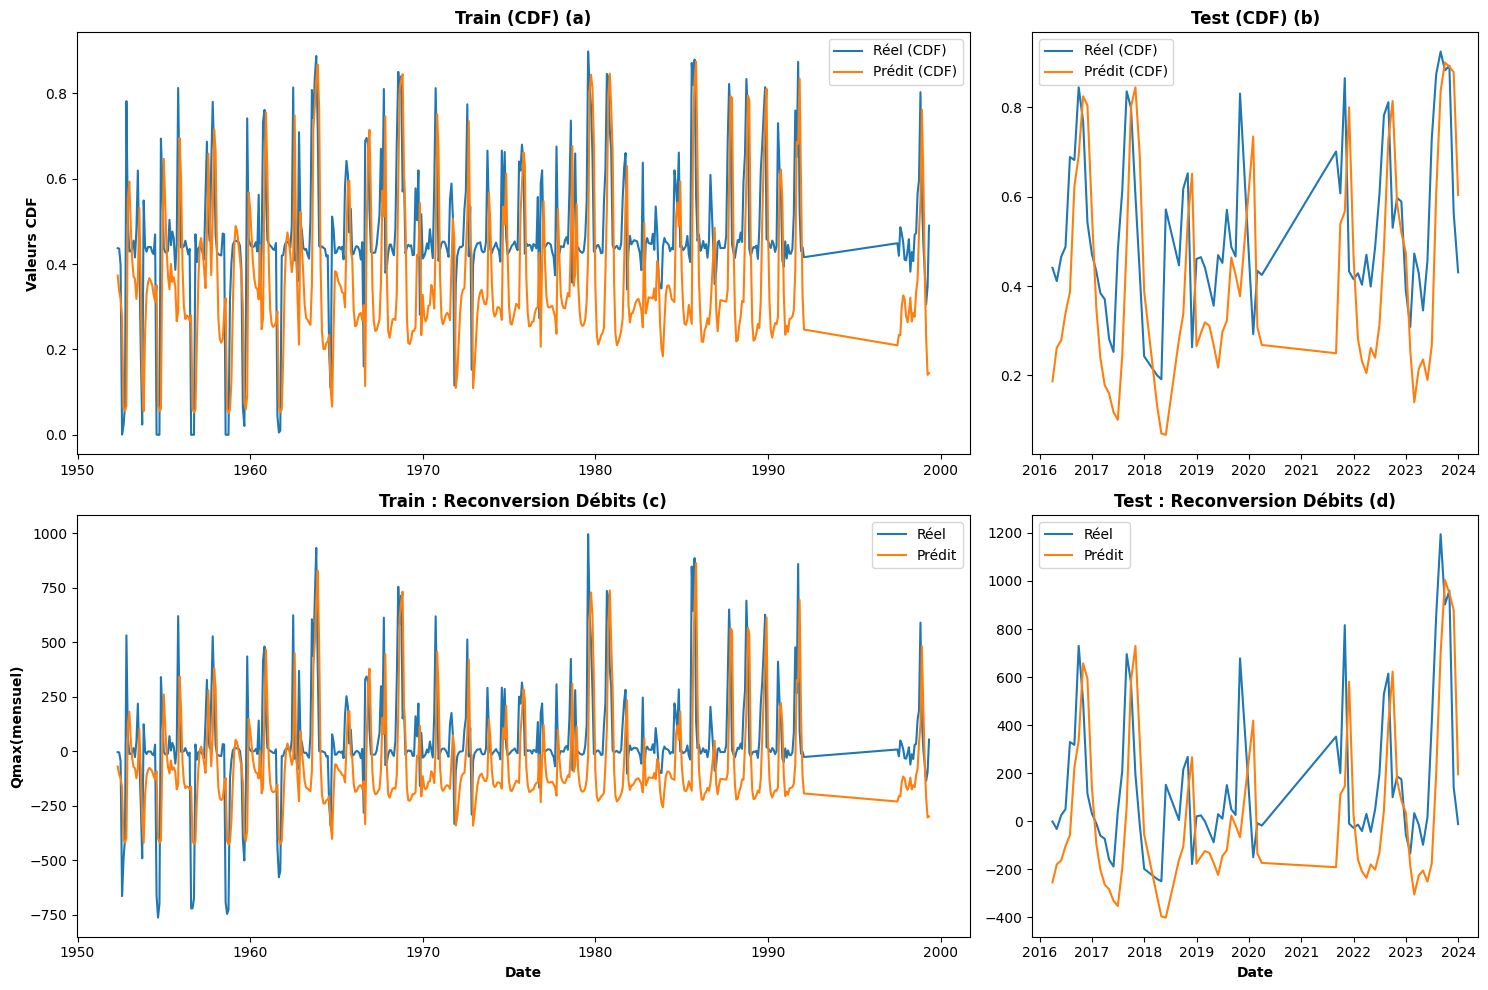

In [160]:
import matplotlib.pyplot as plt

# Configuration des polices
title_p = {'fontsize': 12, 'fontweight': 'bold'}
label_p = {'fontsize': 10, 'fontweight': 'bold'}

# Création de la figure 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10),
                       gridspec_kw={'width_ratios': [2, 1]})

# Définition des longueurs pour éviter l'erreur de dimension
n_train = output_data.shape[0]
n_test = test_output.shape[0]

# ==========================================
# LIGNE 1 : ESPACE CDF (PROBABILITÉS)
# ==========================================

# TRAIN CDF (Utilise les n_train premiers éléments après le lag)
axes[0, 0].plot(t_month_date_series[lag:lag+n_train], output_data, label='Réel (CDF)')
axes[0, 0].plot(t_month_date_series[lag:lag+n_train], t_remainder_train_cdf, label='Prédit (CDF)')
axes[0, 0].set_title("Train (CDF) (a)", **title_p)
axes[0, 0].set_ylabel("Valeurs CDF", **label_p)
axes[0, 0].legend()

# TEST CDF (Utilise les n_test derniers éléments de la série de dates)
axes[0, 1].plot(t_month_date_series[-n_test:], test_output, label='Réel (CDF)')
axes[0, 1].plot(t_month_date_series[-n_test:], t_remainder_test_cdf, label='Prédit (CDF)')
axes[0, 1].set_title("Test (CDF) (b)", **title_p)
axes[0, 1].legend()

# ==========================================
# LIGNE 2 : ESPACE DÉBITS (RECONVERSION)
# ==========================================

# TRAIN REMAINDER
axes[1, 0].plot(t_month_date_series[lag:lag+n_train], t_remainder[lag:lag+n_train], label='Réel')
axes[1, 0].plot(t_month_date_series[lag:lag+n_train], t_remainder_train_pred, label='Prédit')
axes[1, 0].set_title("Train : Reconversion Débits (c)", **title_p)
axes[1, 0].set_ylabel("Qmax(mensuel)", **label_p)
axes[1, 0].set_xlabel("Date", **label_p)
axes[1, 0].legend()

# TEST REMAINDER
axes[1, 1].plot(t_month_date_series[-n_test:], t_remainder[-n_test:], label='Réel')
axes[1, 1].plot(t_month_date_series[-n_test:], t_remainder_test_prd, label='Prédit')
axes[1, 1].set_title("Test : Reconversion Débits (d)", **title_p)
axes[1, 1].set_xlabel("Date", **label_p)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [161]:
# @title Trend Forcasting

# @title Trend Forcasting
lag = 12

model_trend = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation=None)
])

model_trend.build(input_shape=(None, lag))
model_trend.compile(
    optimizer=tf.optimizers.Adam(
        tf.optimizers.schedules.ExponentialDecay(
            0.01, 50, 0.9
        )
    ),
    loss=tf.losses.MeanSquaredError()
)

In [162]:
train_frac = 0.85
# n = Ttou_month_max.dropna
n = t_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

In [163]:
input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(t_trend[i - lag:i])
    output_data.append([t_trend[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

print(f'Input Data Shape: {input_data.shape}')
print(f'Output Data Shape: {output_data.shape}')

Input Data Shape: (496, 12)
Output Data Shape: (496, 1)


/tmp/ipykernel_49477/2874535214.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_data.append([t_trend[i]])


In [164]:
history = model_trend.fit(input_data,
                          output_data,
                          verbose = 0,
                          # callbacks = ,
                          epochs=100)

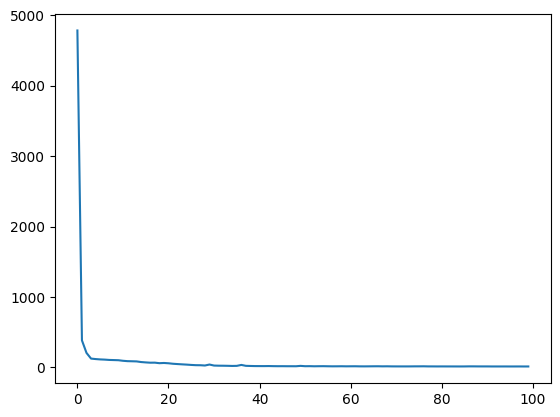

In [165]:
plt.plot(history.history['loss'])

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


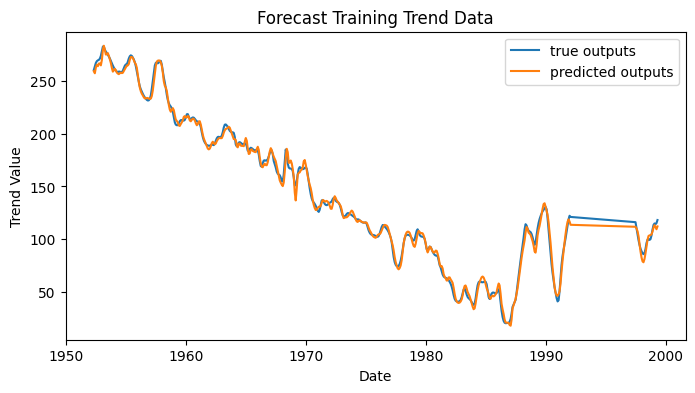

In [166]:
# @title Train trend Forcastiing
t_trend_train_pred = model_trend.predict(input_data)

plt.figure(figsize=(8, 4))
plt.plot(
    t_month_date_series[lag: num_train],
    output_data,
    label='true outputs'
)
plt.plot(
    t_month_date_series[lag: num_train],
    t_trend_train_pred,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('Trend Value')
plt.legend()
plt.title('Forecast Training Trend Data')
plt.show()

In [168]:
test_frac = 0.88
n = t_remainder_series_cdf.shape[0]
num_test = int(n * test_frac)

In [169]:
# @title Test Trend Forcast
test_input = []
test_output = []

for i in range(num_test, n):
    test_input.append(t_trend[i - lag:i])
    test_output.append([t_trend[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (72, 12)
Test Output Data Shape: (72, 1)


/tmp/ipykernel_49477/776504295.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_output.append([t_trend[i]])


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


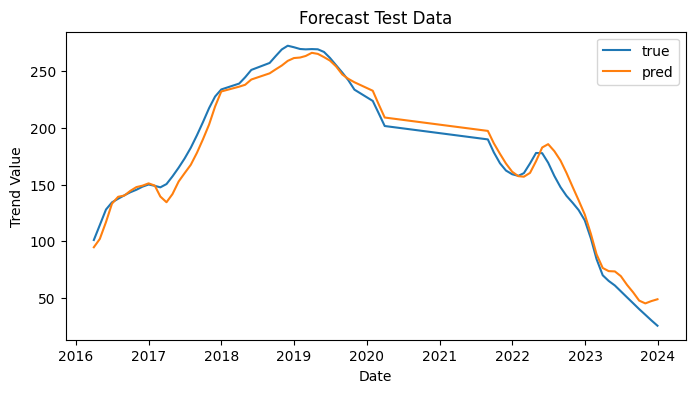

In [170]:
# @title Prédiction de la tedence sur les données de teste
t_trend_test_pred = model_trend.predict(test_input)

plt.figure(figsize=(8, 4))

plt.plot(
    t_month_date_series[num_test:],
    test_output,
    label='true'
)
plt.plot(
    t_month_date_series[num_test:],
    t_trend_test_pred,
    label='pred'
)
plt.xlabel('Date')
plt.ylabel('Trend Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

In [172]:
test_frac = 0.88
n = t_remainder_series_cdf.shape[0]
num_test = int(n * test_frac)

In [173]:
# @title Saisonality forcasting
t_seasonality_train = t_seasonal[:num_train][lag:]

season_values = t_seasonal[:num_train][-12:]
t_seasonality_test = np.zeros((n - num_test, 1))

for i in range(n - num_test):
    t_seasonality_test[i] = season_values[i % 12]

/tmp/ipykernel_49477/4285479429.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  t_seasonality_test[i] = season_values[i % 12]


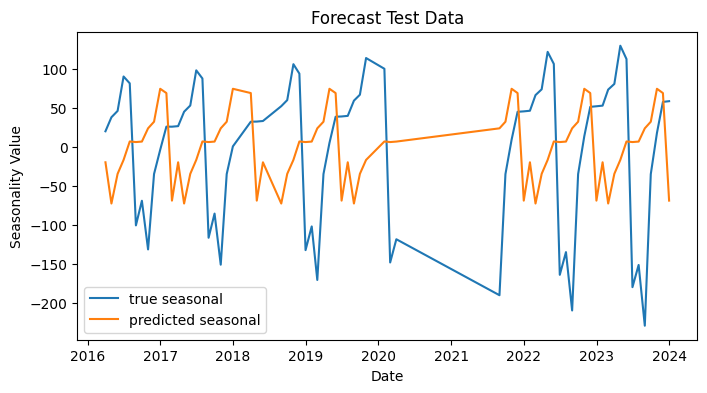

In [174]:
# @title Prédiction de la saisonnalité sur les données de teste
plt.figure(figsize=(8, 4))

plt.plot(
    t_month_date_series[num_test:],
    t_seasonal[num_test:],
    label='true seasonal'
)
plt.plot(
    t_month_date_series[num_test:],
    t_seasonality_test,
    label='predicted seasonal'
)
plt.xlabel('Date')
plt.ylabel('Seasonality Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

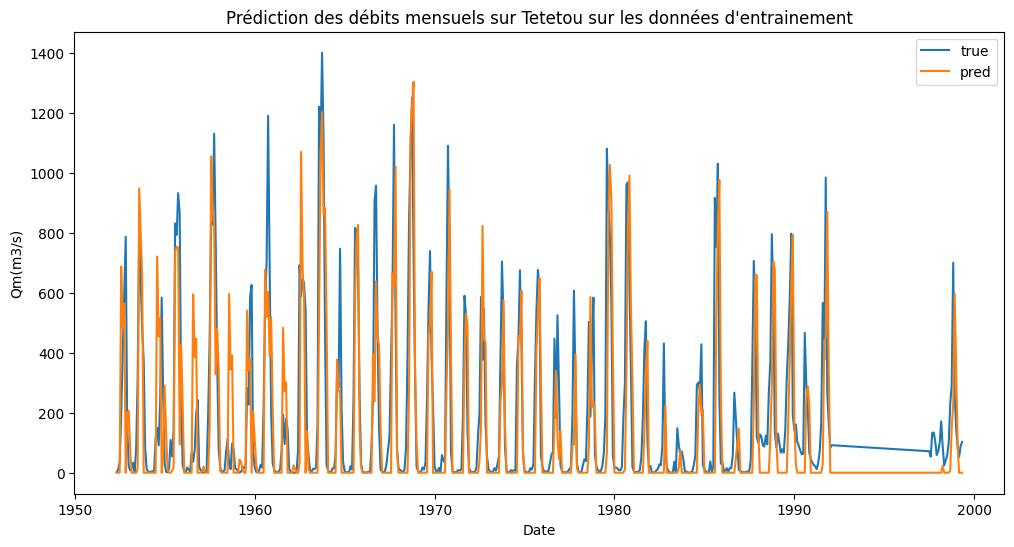

In [176]:
# @title Prédiction des débits mensuels sur les données d'entrainement
pred_train = np.maximum(t_remainder_train_pred.flatten() + t_trend_train_pred.flatten() + t_seasonality_train, 0)
true_train = Ttou_month_max[:num_train][lag:]

plt.figure(figsize=(12, 6))

plt.plot(
    t_month_date_series[lag: num_train],
    true_train,
    label='true'
)
plt.plot(
    t_month_date_series[lag: num_train],
    pred_train,
    label='pred'
)
plt.title("Prédiction des débits mensuels sur Tetetou sur les données d'entrainement")
plt.xlabel('Date')
plt.ylabel('Qm(m3/s)')
plt.legend()
plt.show()

In [177]:
# @title Maximum deschage Forcast
print(t_remainder_train_pred.shape, t_trend_train_pred.shape, t_seasonality_train.shape)
print(t_remainder_test_prd.shape, t_trend_test_pred.shape, t_seasonality_test.shape)

(496, 1) (496, 1) (496,)
(72, 1) (72, 1) (72, 1)


ValueError: x and y must have same first dimension, but have shapes (1,) and (72, 1)

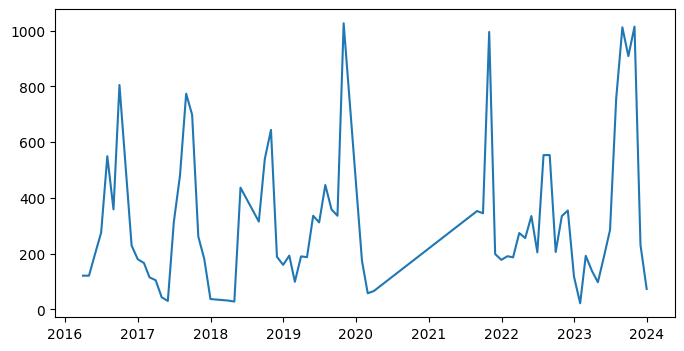

In [180]:
# @title Prédiction des débits mensuels sur les données de teste
pred_test = np.maximum(t_remainder_test_prd + t_trend_test_pred + t_seasonality_test, 0)
true_test = Ttou_month_max[num_test:]

plt.figure(figsize=(8, 4))

plt.plot(
    t_month_date_series[num_test:],
    true_test,
    label='true'
)
plt.plot(
    t_month_date_series[num_test],
    pred_test,
    label='pred'
)
plt.title("Prédiction des débits mensuels sur Dotaicopé sur les données de teste")
plt.xlabel('Date')
plt.ylabel('Qm(m3/s)')
plt.legend()
plt.show()

In [181]:
import matplotlib.pyplot as plt
import numpy as np

# --- Calcul des données ---
pred_train = np.maximum(t_remainder_train_pred.flatten() + t_trend_train_pred.flatten() + t_seasonality_train, 0)
true_train = Ttou_month_max[:num_train][lag:]

pred_test = np.maximum(t_remainder_test_prd + t_trend_test_pred + t_seasonality_test, 0)
true_test = Ttou_month_max[num_test]

# --- Configuration de la figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), gridspec_kw={'width_ratios': [3, 2]})

# Paramètres de style communs
font_title = {'weight': 'bold', 'size': 16}
font_label = {'weight': 'bold', 'size': 14}

# --- Graphique 1 : Entraînement ---
ax1.plot(t_month_date_series[lag: num_train], true_train, label='true', linewidth=1.5)
ax1.plot(t_month_date_series[lag: num_train], pred_train, label='pred', linewidth=1.5, alpha=0.8)

ax1.set_title("Prédiction des débits mensuels sur Dotaicopé (Entraînement)", fontdict=font_title, pad=15)
ax1.set_xlabel('Date', fontdict=font_label)
ax1.set_ylabel('Qm (m3/s)', fontdict=font_label)
ax1.legend(fontsize=12, loc='upper right')
ax1.tick_params(axis='both', which='major', labelsize=12) # Taille des chiffres sur les axes

# --- Graphique 2 : Test ---
ax2.plot(t_month_date_series[num_test+91:], true_test, label='true', linewidth=1.5)
ax2.plot(t_month_date_series[num_test+91:], pred_test, label='pred', linewidth=1.5, alpha=0.8)

ax2.set_title("Prédiction (Test)", fontdict=font_title, pad=15)
ax2.set_xlabel('Date', fontdict=font_label)
ax2.set_ylabel('Qm (m3/s)', fontdict=font_label)
ax2.legend(fontsize=12, loc='upper right')
ax2.tick_params(axis='both', which='major', labelsize=12)

# Ajustement final
plt.tight_layout()

# Pour un rendu très net dans un notebook ou lors de l'enregistrement
# plt.savefig('prediction_debit.png', dpi=300)
plt.show()

KeyError: 526

In [182]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score, f1_score

def get_hydrology_report(y_true, y_pred, label="Modèle", threshold_percentile=75):
    """
    Calcule et affiche un rapport complet de métriques hydrologiques.
    """
    # Nettoyage des données (suppression des NaNs éventuels)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    true = np.array(y_true)[mask]
    pred = np.array(y_pred)[mask]

    # --- 1. Métriques de Régression (Erreur Globale) ---
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)

    # --- 2. Efficacité Hydrologique (NSE & KGE) ---
    # Nash-Sutcliffe Efficiency
    nse = 1 - (np.sum((true - pred)**2) / np.sum((true - np.mean(true))**2))

    # Kling-Gupta Efficiency (KGE 2009)
    r = np.corrcoef(true, pred)[0, 1]
    alpha = np.std(pred) / np.std(true)
    beta = np.mean(pred) / np.mean(true)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    # --- 3. Métriques de Classification (Extrêmes / POT) ---
    threshold = np.percentile(true, threshold_percentile)
    true_bin = (true >= threshold).astype(int)
    pred_bin = (pred >= threshold).astype(int)

    prec = precision_score(true_bin, pred_bin, zero_division=0)
    rec = recall_score(true_bin, pred_bin, zero_division=0)
    f1 = f1_score(true_bin, pred_bin, zero_division=0)

    # Affichage structuré
    print(f"--- Rapport de Performance : {label} ---")
    print(f"Seuil ({threshold_percentile}ème perc.) : {threshold:.4f}")
    print(f"{'RMSE:':<15} {rmse:.4f}")
    print(f"{'MAE:':<15} {mae:.4f}")
    print(f"{'NSE:':<15} {nse:.4f}")
    print(f"{'KGE:':<15} {kge:.4f}")
    print(f"{'Précision:':<15} {prec:.4f}")
    print(f"{'Rappel:':<15} {rec:.4f}")
    print(f"{'F1-Score:':<15} {f1:.4f}")
    print("-" * 40)

    return {
        "rmse": rmse, "mae": mae, "nse": nse, "kge": kge,
        "precision": prec, "recall": rec, "f1": f1
    }

In [ ]:
# @title Sequential
# --- APPLICATION ---

# 1. Sur le Remainder (en utilisant tes variables de test)
# Note : Si tu es en espace CDF [0,1], le seuil sera entre 0 et 1
results_rem = get_hydrology_report(
    t_remainder[num_test+18:],
    t_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 205.0777
RMSE:           302.6221
MAE:            216.5962
NSE:            -0.1287
KGE:            0.2931
Précision:      0.5172
Rappel:         0.8333
F1-Score:       0.6383
----------------------------------------


In [ ]:
# 2. Sur la Reconstitution Totale (Débits réels)
results_final = get_hydrology_report(
    true_test[:72],
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 335.6190
RMSE:           386.3151
MAE:            299.3264
NSE:            -2.0510
KGE:            -0.1409
Précision:      0.2727
Rappel:         0.4737
F1-Score:       0.3462
----------------------------------------


In [ ]:
# @title LSTM

# @title Sequential
# --- APPLICATION ---

# 1. Sur le Remainder (en utilisant tes variables de test)
# Note : Si tu es en espace CDF [0,1], le seuil sera entre 0 et 1
results_rem = get_hydrology_report(
    t_remainder[num_test+18:],
    t_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 211.1460
RMSE:           281.5830
MAE:            200.5632
NSE:            0.1678
KGE:            0.5808
Précision:      0.5238
Rappel:         0.6111
F1-Score:       0.5641
----------------------------------------


In [ ]:
# 2. Sur la Reconstitution Totale (Débits réels)
results_final = get_hydrology_report(
    true_test[:72],
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 335.6190
RMSE:           401.6618
MAE:            290.6125
NSE:            -2.3400
KGE:            -0.1632
Précision:      0.3200
Rappel:         0.4211
F1-Score:       0.3636
----------------------------------------


In [201]:
t_remainder[:72].shape, t_remainder_test_prd.flatten().shape

((72,), (72,))

In [202]:
# @title Model GRU

results_rem = get_hydrology_report(
    t_remainder[:72],
    t_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 13.3452
RMSE:           430.9699
MAE:            342.1557
NSE:            -0.9982
KGE:            -0.6176
Précision:      0.2759
Rappel:         0.4444
F1-Score:       0.3404
----------------------------------------


In [184]:
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 377.9570
RMSE:           310.8789
MAE:            237.5790
NSE:            -0.4410
KGE:            0.3688
Précision:      0.4706
Rappel:         0.4444
F1-Score:       0.4571
----------------------------------------


-------------------------------
                                  LSTM - GRU - RF

In [ ]:
# @title Préparation et Mise en Forme (Data Engineering)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

df = Ttou_month_max

# Fonction pour le Nash-Sutcliffe Efficiency (NSE)
def compute_nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))

# 1. Préparation des séquences
def create_dataset(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Chargement (Assurez-vous que df est trié par date)
# df = pd.read_csv('votre_fichier.csv')
values = df['Qj'].values.reshape(-1, 1)

# Normalisation
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(values)

look_back = 12 # On utilise 1 an d'historique pour prédire le mois suivant
X, y = create_dataset(scaled_data, look_back)

# Split Train/Test (chronologique)
train_size = int(len(X) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape pour LSTM/GRU [samples, time steps, features]
X_train_dl = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test_dl = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
# @title RF
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train) # RF prend les données à plat

In [ ]:
# @title LSTM - GRU
def build_model(model_type="LSTM"):
    model = Sequential()
    if model_type == "LSTM":
        model.add(LSTM(64, activation='relu', input_shape=(look_back, 1)))
    else:
        model.add(GRU(64, activation='relu', input_shape=(look_back, 1)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_model("LSTM")
gru_model = build_model("GRU")

# Entraînement silencieux pour la clarté
lstm_model.fit(X_train_dl, y_train, epochs=100, batch_size=32, verbose=0)
gru_model.fit(X_train_dl, y_train, epochs=100, batch_size=32, verbose=0)

In [ ]:
# @title Metrics evaluation
def get_metrics(model, X_input, y_true, name, is_dl=True):
    pred = model.predict(X_input)
    # Inverse scaling
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1))
    pred_inv = scaler.inverse_transform(pred.reshape(-1, 1))

    return {
        "Modèle": name,
        "RMSE": np.sqrt(mean_squared_error(y_true_inv, pred_inv)),
        "MAE": mean_absolute_error(y_true_inv, pred_inv),
        "R2": r2_score(y_true_inv, pred_inv),
        "NSE": compute_nse(y_true_inv, pred_inv),
        "Pred": pred_inv,
        "True": y_true_inv
    }

results_test = [
    get_metrics(rf_model, X_test, y_test, "Random Forest", False),
    get_metrics(lstm_model, X_test_dl, y_test, "LSTM"),
    get_metrics(gru_model, X_test_dl, y_test, "GRU")
]

summary = pd.DataFrame(results_test).drop(['Pred', 'True'], axis=1)
print(summary)

In [ ]:
def get_metrics(model, X_input, y_true, name, is_dl=True, threshold=0.75):
    # Prédiction
    if is_dl:
        pred = model.predict(X_input, verbose=0)
    else:
        pred = model.predict(X_input)

    # Inversion du scaling pour rester en m3/s
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
    pred_inv = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()

    # Calcul de l'erreur relative par point
    # On évite la division par zéro pour les débits nuls (étiage)
    relative_error = np.abs((y_true_inv - pred_inv) / (y_true_inv + 1.0))

    # Accuracy within threshold : pourcentage de points où l'erreur < seuil
    accuracy_threshold = np.mean(relative_error <= threshold) * 100

    return {
        "Modèle": name,
        "RMSE": np.sqrt(mean_squared_error(y_true_inv, pred_inv)),
        "MAE": mean_absolute_error(y_true_inv, pred_inv),
        "R2": r2_score(y_true_inv, pred_inv),
        "NSE": compute_nse(y_true_inv, pred_inv),
        f"Acc_{int(threshold*100)}% (%)": accuracy_threshold,
        "Pred": pred_inv,
        "True": y_true_inv
    }

# Relancer l'évaluation
results_test = [
    get_metrics(rf_model, X_test, y_test, "Random Forest", False),
    get_metrics(lstm_model, X_test_dl, y_test, "LSTM"),
    get_metrics(gru_model, X_test_dl, y_test, "GRU")
]

summary = pd.DataFrame(results_test).drop(['Pred', 'True'], axis=1)
print(summary.round(3))

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_classification_metrics(y_true, y_pred, threshold_percentile=75):
    # 1. Calcul du seuil réel sur les données observées
    threshold = np.percentile(y_true, threshold_percentile)

    # 2. Transformation en labels binaires (1 = Crue, 0 = Normal)
    true_extreme = (y_true >= threshold).astype(int)
    pred_extreme = (y_pred >= threshold).astype(int)

    # 3. Calcul des métriques de classification
    precision = precision_score(true_extreme, pred_extreme, zero_division=0)
    recall = recall_score(true_extreme, pred_extreme, zero_division=0)
    f1 = f1_score(true_extreme, pred_extreme, zero_division=0)

    return threshold, precision, recall, f1

# Application aux trois modèles
extreme_results = []

for res in results_test: # On utilise les résultats stockés précédemment
    y_t = res['True'].flatten()
    y_p = res['Pred'].flatten()

    thresh, prec, rec, f1 = get_classification_metrics(y_t, y_p)

    extreme_results.append({
        "Modèle": res['Modèle'],
        "Seuil (m3/s)": round(thresh, 2),
        "Précision (Extrêmes)": round(prec, 3),
        "Rappel (Recall)": round(rec, 3),
        "F1-Score": round(f1, 3)
    })

df_extremes = pd.DataFrame(extreme_results)
print(df_extremes)

In [ ]:
# Dates pour les abscisses
dates_train = df.index[look_back : train_size + look_back]
dates_test = df.index[train_size + look_back :]

import matplotlib.pyplot as plt

# Liste des modèles pour la boucle
models_list = [
    (lstm_model, "LSTM", True),
    (gru_model, "GRU", True),
    (rf_model, "Random Forest", False)
]

fig, axes = plt.subplots(3, 2, figsize=(20, 15), sharey=True)
fig.suptitle("Comparaison des Modèles : Entraînement vs Test (Tetetou)", fontsize=20)

for i, (model, name, is_dl) in enumerate(models_list):
    # --- PRÉDICTIONS ---
    if is_dl:
        pred_train = model.predict(X_train_dl, verbose=0)
        pred_test = model.predict(X_test_dl, verbose=0)
    else:
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)

    # Inversion du scaling
    y_train_true_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
    y_train_pred_inv = scaler.inverse_transform(pred_train.reshape(-1, 1))
    y_test_true_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_test_pred_inv = scaler.inverse_transform(pred_test.reshape(-1, 1))

    # --- COLONNE 1 : ENTRAÎNEMENT ---
    axes[i, 0].plot(dates_train, y_train_true_inv, label='Observé', color='royalblue', alpha=0.7)
    axes[i, 0].plot(dates_train, y_train_pred_inv, label='Prédit', color='darkorange', linestyle='--')
    axes[i, 0].set_title(f"{name} - Entraînement")
    axes[i, 0].set_ylabel("Débit (m³/s)")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].legend()

    # --- COLONNE 2 : TEST ---
    axes[i, 1].plot(dates_test, y_test_true_inv, label='Observé', color='royalblue', alpha=0.7)
    axes[i, 1].plot(dates_test, y_test_pred_inv, label='Prédit', color='crimson', linestyle='--')
    axes[i, 1].set_title(f"{name} - Test")
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].legend()

# Ajustement automatique des dates sur l'axe X
for ax in axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=30)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()